<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.875 · Deep Learning · PEC2</p>
<p style="margin: 0; text-align:right;">2024-2 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 2: Redes neuronales recurrentes con Keras


<u>Consideraciones generales</u>:

- Esta PEC debe realizarse de forma **estrictamente individual**. Cualquier indicio de copia será penalizado con un suspenso (D) para todas las partes implicadas y la posible evaluación negativa de la asignatura de forma íntegra.
- Es necesario que el estudiante indique **todas las fuentes** que ha utilizado para la realización de la PEC. De no ser así, se considerará que el estudiante ha cometido plagio, siendo penalizado con un suspenso (D) y la posible evaluación negativa de la asignatura de forma íntegra.

<u>Formato de la entrega</u>:

- Algunos ejercicios pueden suponer varios minutos de ejecución, por lo que la entrega debe hacerse en **formato notebook** y en **formato html**, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a HTML desde el menú File $\to$ Download as $\to$ HTML.
- Existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de la actividad. Para cambiar el tipo de celda a este tipo, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

# 0. Contexto y carga de librerías

# Redes Neuronales Recurrentes

Las **redes neuronales recurrentes (RNNs)** se basan justamente en esta idea: son redes diseñadas para procesar secuencias, manteniendo un estado oculto que evoluciona con el tiempo y resume la información relevante del pasado. Así, las RNN permiten capturar patrones temporales y contextuales mucho más largos que los modelos clásicos de $n$-gramas, siendo una herramienta fundamental para tareas como generación de texto, análisis de sentimientos, traducción automática, entre otras.

**En esta práctica, en la primera parte exploraremos cómo funcionan las RNNs desde cero, implementando y entrenando una red básica para tareas de modelado de lenguaje. En la segunda, utilizaremos modelos ya implementados para aplicarlo a un problema real de estimación del consumo de energía.**


In [1]:
# Mount Google drive
from google.colab import drive
drive.mount("/content/drive") #, force_remount=True

# Change the working directory
%cd /content/drive/"My Drive"/"Colab Notebooks"/DEEP_LEARNING_0/PEC02_RNN

Mounted at /content/drive
/content/drive/My Drive/Colab Notebooks/DEEP_LEARNING_0/PEC02_RNN


In [2]:
#!pip install tensorflow #  "tensorflow<2.11"

In [3]:
# LIBRERIAS NECESARIAS
import tensorflow as tf
import numpy as np

# 1. Implementar una RNN desde Cero (Paso a Paso)

**1.1. Implementación RNN (Forward Pass) desde Cero**

**¿Qué es una RNN?**  
Una Red Neuronal Recurrente (RNN) es una arquitectura diseñada para procesar datos secuenciales (como texto o series de tiempo). Su característica clave es el **estado oculto** (`h_t`), que actúa como memoria dinámica almacenando información contextual de todos los pasos anteriores. A diferencia de los modelos de n-gramas, las RNNs pueden capturar dependencias a *largo plazo* mediante esta memoria recurrente, procesando secuencias de longitud variable de manera eficiente.

**Formulación Matemática**  
En cada paso de tiempo `t`, la RNN realiza dos acciones fundamentales:

1. **Actualización del estado oculto**:  
   Combina la entrada actual `x_t` y el estado oculto anterior `h_{t-1}` mediante una transformación lineal seguida de una no linealidad (usualmente `tanh`):

   $$
   h_t = \tanh(\underbrace{W_{xh} x_t}_{\text{Contribución actual}} + \underbrace{W_{hh} h_{t-1}}_{\text{Memoria pasada}} + b_h)
   $$

   - **$W_{xh}$**: Matriz de pesos que proyecta la entrada al espacio oculto (dimensión: `d × H`).
   - **$W_{hh}$**: Matriz de pesos recurrentes que actualiza la memoria (dimensión: `H × H`).
   - **$b_h$**: Vector de sesgo (dimensión: `H`).
   - **`tanh`**: Función de activación que acota valores entre [-1, 1], estabilizando gradientes.

2. **Generación de salida (se ve en el ejercicio 1.2.)**:  
   Para modelado del lenguaje, se suele añadir una capa lineal adicional que mapea $h_t$ a logits para predecir el próximo token:
   $$
   o_t = W_{ho} h_t + b_o
   $$
   Donde $W_{ho}$ (dimensión: `H × |Vocabulario|`) y $b_o$ son parámetros de salida.

**Flujo de Información**  
En cada paso $t$, la RNN procesa secuencialmente:
- Toma la entrada actual $x_t$ (ej: embedding de un carácter).
- Combina $x_t$ con el estado anterior $h_{t-1}$ para calcular $h_t$.
- Usa $h_t$ para predecir el siguiente elemento en la secuencia.

Esta recurrencia permite que la información fluya a través del tiempo, dando a la RNN su capacidad de *recordar* patrones temporales.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.75 pts.]:</strong> Define un modelo de Red Neuronal Recurrente (RNN) siguiendo los pasos para construir la arquitectura del modelo descrita a continuación:</p>
</div>

**Instrucciones para Implementar la RNN (Paso a Paso):**

**1. Crea una clase `RNNScratch`:**
-  Para ello, hereda de `tf.Module` para aprovechar las utilidades de TensorFlow-
- Define los siguientes atributos en el constructor:
  - `num_inputs`: Dimensión de los vectores de entrada (ej: tamaño del vocabulario o de embeddings).
  - `num_hiddens`: Dimensión del estado oculto (`H`).
  - `sigma`: Desviación estándar para inicialización de pesos.

**2. Dentro del constructor, define `W_xh`, `W_hh` y `b_h` como variables entrenables de TensorFlow.**
- **`W_xh`**: Pesos para proyectar la entrada `x_t` al espacio oculto.
  - Forma: `(num_inputs, num_hiddens)`.
  - Inicializado con valores aleatorios de distribución normal escalados por `sigma`.
- **`W_hh`**: Pesos recurrentes para propagar el estado oculto.
  - Forma: `(num_hiddens, num_hiddens)`.
  - Inicializado igual que `W_xh`.
- **`b_h`**: Sesgo del estado oculto.
  - Inicializado con ceros (forma `(num_hiddens,)`).

**3. Implementar el método `forward`:**
- Esta función recibirá dos parámetros:
  - `inputs`: Tensor de forma `(T, batch_size, num_inputs)`, donde `T` es la longitud de la secuencia.
  - `state`: Estado oculto inicial (si es `None`, se inicializa con ceros).
- La lógica dentro de esta funcion es la siguiente:
  - Verificamos si `state` no se proporciona (es None), inicializarlo como tensor de ceros con forma `(batch_size, num_hiddens)`.
  - A continuación,  es necesario iterar sobre cada paso de tiempo `T` (ej: bucle for):
    - Para cada X que recibimos que tiene la forma `(batch_size, num_inputs)` en :
      - Calcular `tf.matmul(X, self.W_xh)`: Proyección de la entrada actual.
      - Calcular `tf.matmul(state, self.W_hh)`: Contribución del estado anterior.
      - Sumar ambos términos y el sesgo `self.b_h`.
      - Aplicar `tanh` para obtener el nuevo estado: `state = tf.tanh(...)`.
    - Almacenar el estado en una lista de `outputs` (que tiene que ser previamente inicializada).

**Pistas:**
- **Batch Processing**: Cada `X` en el bucle tiene forma `(batch_size, num_inputs)`, permitiendo procesar múltiples secuencias en paralelo.
- **Recurrencia**: El estado `state` se actualiza en cada paso y se pasa al siguiente, manteniendo la memoria temporal.
- **Salida**: `outputs` es una lista con los estados ocultos en cada paso, útil para conectar a capas posteriores (ej: predicción de tokens).

In [4]:
# 1.Crea una clase RNNScratch
class RNNScratch(tf.Module):
  # Constructor
    def __init__(self, num_inputs, num_hiddens, sigma=0.01, name=None):
        super().__init__(name=name)

        # 2. Define los siguientes atributos en el constructor
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma

        # 3. Define como variables entrenables de Tensorflow
        # Matriz de pesos que proyecta la entrada al espacio oculto (dimensión: `d × H`)
        self.W_xh = tf.Variable(tf.random.normal([num_inputs, num_hiddens], stddev=sigma), name='W_xh')

        # Matriz de pesos recurrentes que actualiza la memoria (dimensión: `H × H`
        self.W_hh = tf.Variable(tf.random.normal([num_hiddens, num_hiddens], stddev=sigma), name='W_hh')

        # Vector de sesgo (dimensión: `H`)
        self.b_h = tf.Variable(tf.zeros([num_hiddens]), name='b_h')

    # 4. Implementar el método forward
    def forward(self, inputs, state=None):

        # Tensor de forma `(T, batch_size, num_inputs)`, donde `T` es la longitud de la secuencia
        T = tf.shape(inputs)[0]
        batch_size = tf.shape(inputs)[1]
        num_inputs = tf.shape(inputs)[2]

        # Verificamos si `state` no se proporciona (es None), inicializarlo como tensor de ceros con forma `(batch_size, num_hiddens)`
        if state is None:
            state = tf.zeros([batch_size, self.num_hiddens])

        # Lista para almacenar los estados ocultos en cada paso
        outputs = []

        # Iterar sobre cada paso de tiempo T
        for time_step in range(T):
            # Para cada X que recibimos que tiene la forma (batch_size, num_inputs)
            x_t = inputs[time_step, :, :]

            # Proyección de la entrada actual
            xh_t = tf.matmul(x_t, self.W_xh)

            # Contribución del estado anterior
            hh_t = tf.matmul(state, self.W_hh)

            # Sumar ambos términos y el sesgo
            h_t = xh_t + hh_t + self.b_h

            # Aplicar tanh para obtener el nuevo estado
            state = tf.tanh(h_t)
            outputs.append(state)
        return outputs, state
        #return tf.stack(outputs, axis=1), state

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.25]:</strong> Verifica su funcionamiento con la siguiente celda y responde a la siguiente pregunta en una sola línea ¿De qué está compuesto la variable 'outputs'?</p>
</div>

**Respuesta:**
`Output` contiene para cada entrada (Xt) en el tiempo (t) la salida del estado oculto (ht) - memoria -.


In [5]:
# Prueba funcionamiento de la implementación
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100

# Llamada a la clase RNNScratch
rnn = RNNScratch(num_inputs, num_hiddens)

# Creamos un Tensor Dummy de dimension 100x2x16
X = tf.ones((num_steps, batch_size, num_inputs))

# Datos cada estado oculto, datos de estado final (ht)
outputs, state = rnn.forward(X)  # Use forward() instead of calling rnn directly

#print("Pesos por recurrencia: ", outputs.shape, '\n')
print("Pesos por recurrencia: ", len(outputs), '\n')
print("Composición de una secuencia: ", outputs[0],'\n')
print("Estado final: ", state.shape)

Pesos por recurrencia:  100 

Composición de una secuencia:  tf.Tensor(
[[ 3.0547380e-07  5.6990273e-02 -3.8324483e-02  2.7570263e-02
   5.8039840e-02  3.8993403e-02  5.2318912e-02  3.5073943e-02
  -3.6799738e-03  5.0942618e-02  8.2406208e-02  2.3769323e-02
   8.9246314e-03  3.2766838e-02  6.2598415e-02  4.7817249e-02
  -6.9018085e-03 -6.9982200e-03 -4.9445778e-05 -2.0435823e-02
   2.0742638e-02 -1.7860182e-02  5.4478063e-03 -4.8197892e-02
  -3.3859804e-02  8.9668611e-04 -1.1390434e-03  2.0695560e-02
  -5.6996118e-02 -2.4836902e-02  3.5320796e-02  5.0023794e-02]
 [ 3.0547380e-07  5.6990273e-02 -3.8324483e-02  2.7570263e-02
   5.8039840e-02  3.8993403e-02  5.2318912e-02  3.5073943e-02
  -3.6799738e-03  5.0942618e-02  8.2406208e-02  2.3769323e-02
   8.9246314e-03  3.2766838e-02  6.2598415e-02  4.7817249e-02
  -6.9018085e-03 -6.9982200e-03 -4.9445778e-05 -2.0435823e-02
   2.0742638e-02 -1.7860182e-02  5.4478063e-03 -4.8197892e-02
  -3.3859804e-02  8.9668611e-04 -1.1390434e-03  2.0695560e-

Nota pesonal:

- `batch_size`: número de entradas a procesar en paralelo.
- `num_inputs`: tamaño del vector en cada parada en la secuencia (t).
- `num_hiddens`: total de unidades ocultas, esto es la dimensión del estado oculto (h)
- `num_steps`: número de pasos en la secuencia.

`batch_size` son 2 entradas a procesar en paralelo (ejemplo si tratamos texto: "oración 1", "oración 2"). `num_inputs`, las entradas se representan como un vector de 16 atributos. `num_steps` cada una de estas entradas tienen la longitud de 100 secuencias (esto es que la oración contienen 100 tokens: "yo" "como" "..." "cien."). Finalmente, la RRN tiene que mantener en memoria un vector de 32 estados - `num_hiddens`.

- https://www.tensorflow.org/api_docs/python/tf/Variable

- https://www.tensorflow.org/api_docs/python/tf/random/normal


Finalmente, ¿cuál es la diferencia entre `output` y `state` en la clase que hemos creado?
- `output` contiene los resultados de cada estado oculto por entrada (xt) en la secuencia (t) mientras que `state` contiene solo el último resultado del estado oculto en la secuencia. Analogía: si pensamos en términos de película, el output es la película entera mientras que state es el último frame de la peícula.

## 1.2. RNN para Modelo del Lenguaje

Ahora que ya tienes implementada la clase `RNNScratch`, el siguiente paso es usarla como base para construir un **modelo de lenguaje**. Este tipo de modelos son la base de sistemas de autocompletado de texto, predicción de palabras o generación de texto.

### ¿Qué cambia ahora?

Cuando trabajamos con modelos de lenguaje, **las entradas y las salidas pertenecen al mismo vocabulario**. Por ejemplo, si estás entrenando un modelo para predecir la próxima palabra en una frase, tanto la palabra actual (entrada) como la siguiente (salida esperada) son palabras del vocabulario. Esto significa que:

- Cada palabra se codifica como un vector (por ejemplo, one-hot).
- La dimensión de estos vectores es igual al tamaño del vocabulario.
- La salida del modelo debe ser una predicción sobre cuál es el próximo token, también expresado en términos del vocabulario.

### ¿Qué se proporciona?
- La clase `RNNLMScratch`.

- **`__init__`**: recibe la RNN previamente definida, el tamaño del vocabulario (ya que tanto la entrada como la salida están en este espacio) y una tasa de aprendizaje.
  
- **`init_params`**: define los pesos y sesgos de la capa de salida. Esta capa toma el estado oculto en cada paso y genera una distribución sobre el vocabulario (probabilidad de que cada palabra sea la siguiente).



In [6]:
class RNNLMScratch(tf.Module):
    """ RNN-based language model """
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()

        self.init_params()

    def init_params(self):
        self.W_hq = tf.Variable(tf.random.normal(
            (self.rnn.num_hiddens, self.vocab_size)) * self.rnn.sigma)
        self.b_q = tf.Variable(tf.zeros(self.vocab_size))

## 1.2.1. Codificación One-Hot

¿Qué es la codificación one-hot? Cada token (carácter) se representa como un vector de longitud igual al tamaño del vocabulario, con un 1 en el índice correspondiente al token y 0 en las demás posiciones.

Por ejemplo, si `vocab = {'a':0, 'b':1, 'c':2}`, entonces:
- `one_hot(0)` → `[1, 0, 0]`
- `one_hot(2)` → `[0, 0, 1]`

In [7]:
class RNNLMScratch(tf.Module):
    """
    RNN-based language model
    Args:
            rnn: referencia a la clase RNNScratch definida anteriormente.
            vocab_size: tamaño del vocabulario.
            lr: tasa de aprendizaje.
    """
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()
        # Definición atributos en el constructor
        self.rnn = rnn
        self.vocab_size = vocab_size
        self.lr = lr

        # Inicializamos los atributos
        self.init_params()

    # Método convierte los resultados del estado oculto (hidden state) en probabilidades del próximo token
    def init_params(self):
        # Peso del vocabulario en el corpus en el estado oculto inicializados con ruido Gaussiano y escala Sigma
        self.W_hq = tf.Variable(tf.random.normal(
            (self.rnn.num_hiddens, self.vocab_size)) * self.rnn.sigma)
        # Peso del bias en la salida
        self.b_q = tf.Variable(tf.zeros(self.vocab_size))

    # Añadimos la funcion one-hot
    def one_hot(self, X):
        return tf.one_hot(tf.transpose(X), self.vocab_size)

Probamos el funcionamiento de la clase `RNNLMScratch`:

In [8]:
# Usamos los datos de prueba para verificar el funcionamiento de la clase
batch_size, vocab_size, num_hiddens, num_steps = 2, 16, 32, 100

# Simulamos la entrada (Token ID) en formato Tensor
X = tf.constant(np.random.randint(0, vocab_size, size=(batch_size, num_steps)), dtype=tf.int32)

# Instanciamos RNNScratch
rnn = RNNScratch(num_inputs=vocab_size, num_hiddens=num_hiddens)

# Instanciamos RNNLMScratch
lm = RNNLMScratch(rnn=rnn, vocab_size=vocab_size)

# Convert to one-hot (seq_len, batch_size, vocab_size)
X_onehot = lm.one_hot(X)

# Test forward pass
outputs_history, final_state = lm.rnn.forward(X_onehot)

print("X shape: ", X.shape)
print("Input Token Indices:\n", X.numpy(), '\n')
print("One-hot shape:", X_onehot.shape, '\n')
print("One-hot Encoded Input:\n", X_onehot[0], '\n')
# print("Output hidden states:")
#for i, out in enumerate(outputs_history):
    #print(f"Timestep {i} shape: {out.shape}")
print("Final hidden state shape:", final_state.shape)

X shape:  (2, 100)
Input Token Indices:
 [[10 13 15 10  3  7  1  6  0 14 15  7  5  7  6 14  2  4  7  4  0  3  2  6
   4 11 12  4  6 12  5 13  8 12  5  5 10  1 15 14  9 15  8  1 10 15  4 15
   4  0  6 10  8 12  6 15  3 14  2  8 15  5  6  4  0 11 15 10  0 15  0  0
   8 13 13  9  3  0 12  5  9  7  5  8  5 10  7  7  0  0  9  2 15  3 13  1
  12 12 15  8]
 [ 8  6 14  5 10  7  4  6 10  2 10 15  5 14  8 12  8  3 11 11  6  7  4  5
   2 15  7  8 11 11 13  8  2  7  1  6  4  1  3  1  3  5  9 12 11  7  6 13
   1 12  3 15  2  0 12  6  2  1  6  6 15 12 12  2  1  2  8  7 14  2  6 12
   5  8 14  2  4  5  3  1  4  7  2 10  1  6  5 11 14  0 13 11  8  2  1  6
   3  2  3  4]] 

One-hot shape: (100, 2, 16) 

One-hot Encoded Input:
 tf.Tensor(
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]], shape=(2, 16), dtype=float32) 

Final hidden state shape: (2, 32)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.5 pts.]:</strong> ¿Podrías decir qué es lo que hace la función anterior one_hot sobre la matriz X dado un tamaño de vocabulario?</p>
</div>

**Respuesta**

X es un conjunto de índices que representan un token con no más de 16 caracteres dado un texto de longitud 100. La función one_hot coge cada índice, mapea el token encontrado con un 1 y rellena el resto del espacio con un 0. La transposición se realiza para colocar el token en un espacio, de forma horizontal como vertical, para idenificar su localización.

In [9]:
#indices = [0, 1, 2]
#depth = 3
#tf.one_hot(indices, depth)  # output: [3 x 3]

## 1.2.2. Capa de Salida

Después de obtener cada estado oculto $h_t $, queremos proyectarlo al espacio del vocabulario:

$
o_t = h_t W_{hq} + b_q
$

Donde:
- $h_t \in \mathbb{R}^{H} $
- $W_{hq} \in \mathbb{R}^{H \times V} $
- $b_q \in \mathbb{R}^{V} $

$o_t \in \mathbb{R}^{V} $: puntuaciones sin normalizar (logits) sobre el vocabulario.

Por último, es necesario añadir una función `output_layer` dentro de nuestra clase `RNNLMScratch` que toma todos los estados ocultos producidos por la RNN y, para cada uno, aplica la transformación lineal (`W_hq`, `b_q`) que proyecta ese vector al espacio del vocabulario. Luego los apila para devolver un tensor de forma `(batch_size, T, vocab_size)`.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.25 pts.]:</strong> Añade la capa final de la salida en la clase con la que estamos trabajando:</p>
</div>

Implementa el método `output_layer(self, rnn_outputs)` dentro de la clase `RNNLMScratch`, que debe hacer lo siguiente:

1. Recibe una lista de tensores `rnn_outputs`, que son los estados ocultos generados por la RNN en cada paso de la secuencia. Cada uno de estos tensores tiene forma `(batch_size, num_hiddens)`.
2. Para cada estado oculto `H`, aplica una capa lineal:  
  
   $\text{output} = H \cdot W_{hq} + b_q$
   
   Donde:
   - `W_hq` es una matriz de pesos de forma `(num_hiddens, vocab_size)`
   - `b_q` es un vector de sesgo de forma `(vocab_size,)`
3. Devuelve un único tensor de forma `(batch_size, T, vocab_size)`, donde `T` es la longitud de la secuencia.

**Pista**: puedes usar `tf.stack` para convertir la lista de predicciones por paso en un único tensor.

In [10]:
class RNNLMScratch(tf.Module):
    """
    RNN-based language model
    Args:
            rnn: referencia a la clase RNNScratch definida anteriormente.
            vocab_size: tamaño del vocabulario.
            lr: tasa de aprendizaje.
    """
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()
        # Definición atributos en el constructor
        self.rnn = rnn
        self.vocab_size = vocab_size
        self.lr = lr

        # Inicializamos los atributos
        self.init_params()

    # Método convierte los resultados del estado oculto (hidden state) en probabilidades del próximo token
    def init_params(self):
        # Peso del vocabulario en el corpus en el estado oculto inicializados con ruido Gaussiano y escala Sigma
        self.W_hq = tf.Variable(tf.random.normal(
            (self.rnn.num_hiddens, self.vocab_size)) * self.rnn.sigma)
        # Peso del bias en la salida
        self.b_q = tf.Variable(tf.zeros(self.vocab_size))

    # Añadimos la funcion one-hot
    def one_hot(self, X):
        return tf.one_hot(tf.transpose(X), self.vocab_size)
    # Anñadimos método para la salida
    def output_layer(self, rnn_outputs):
        """
        rnn_outputs: lista de tensores con forma (batch_size, num_hiddens)
        """
        # tf.stack transformamos ... de forma que se itera
        H = tf.stack(rnn_outputs, axis=0)  # (T, batch_size, num_hiddens)
        H = tf.transpose(H, perm=[1, 0, 2])  # (batch_size, T, num_hiddens)
        logits = tf.matmul(H, self.W_hq) + self.b_q  # (batch_size, T, vocab_size)
        return logits

In [11]:
# Usamos los datos de prueba para verificar el funcionamiento de la clase
batch_size, vocab_size, num_hiddens, num_steps = 2, 16, 32, 100

# Simulamos la entrada (Token ID) en formato Tensor
X = tf.constant(np.random.randint(0, vocab_size, size=(batch_size, num_steps)), dtype=tf.int32)

# Instanciamos RNNScratch
rnn = RNNScratch(num_inputs=vocab_size, num_hiddens=num_hiddens)

# Instanciamos RNNLMScratch
lm = RNNLMScratch(rnn=rnn, vocab_size=vocab_size)

# Convert to one-hot (seq_len, batch_size, vocab_size)
X_onehot = lm.one_hot(X)

# Test forward pass
outputs_history, final_state = lm.rnn.forward(X_onehot)

# Test output RNNLMS output_layer
logits = lm.output_layer(outputs_history)

print("X shape: ", X.shape)
print("Input Token Indices:\n", X.numpy(), '\n')
print("One-hot shape:", X_onehot.shape, '\n')
print("One-hot Encoded Input:\n", X_onehot[0], '\n')
# print("Output hidden states:")
#for i, out in enumerate(outputs_history):
    #print(f"Timestep {i} shape: {out.shape}")
print("Final hidden state shape:", final_state.shape)
print("Logit Output shape:", logits.shape)
print("Logit Output:\n", logits[0])

X shape:  (2, 100)
Input Token Indices:
 [[13  9  6 13  6  2 15 14 10  7 11 12  4  9  6  4  6  7 15 11  3 15  8  9
   3 15  9  3  0  7 15  5  1  4  4 11 10  9  7 15  2  5  6  0 12  7  9  6
  11 15  5 13  0  1  3 14  2  4  1 11 14 10  4  4  4  6 10  3  7 10 13 13
   8  8 12 15  1 12 13  5  4  3 14  7 15  3  9 12 11  9 10 11 11 13  6 15
   5 13  0  7]
 [10 11  5  7  6 12  0 14 13  7  2  1  6  9  0  6 14  7  4  8  0  6  8  7
  14  0  9  5  2 15  8  1  2 15 10  2 11  6  0  6  6  4  9 10  2  2 13  5
  14  5  4  6  1 13  7 11 12 13  1  2  8 14  4  4  3 12 11 10  8  8 10  7
   3  3  6  8 11  0 14  2 14  7 10  6  9  3  4 12  5  1  4  0  8  6 15  9
   1  8  0  6]] 

One-hot shape: (100, 2, 16) 

One-hot Encoded Input:
 tf.Tensor(
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]], shape=(2, 16), dtype=float32) 

Final hidden state shape: (2, 32)
Logit Output shape: (2, 100, 16)
Logit Output:
 tf.Tensor(
[[-1.2663614e-04  3.5764603e-04 -2.15188

## Ejercicio 1.2.3: Entrenamiento del Modelo de Lenguaje

Vamos a **unir todas las piezas** para construir un **modelo de lenguaje entrenable desde cero**.
Primero copia los siguientes métodos para completar la clase `RNNLMScratch` con los siguientes métodos:
   - `forward`: ejecuta una pasada completa por el modelo (one-hot → RNN → capa de salida).
   - `loss`: calcula la pérdida cross-entropy entre la predicción y la secuencia esperada.
   - `train_step`: realiza una actualización de parámetros usando `GradientTape`.

```python
def forward(self, X, state=None):
    X = self.one_hot(X)  # Convertimos a one-hot: (T, batch_size, vocab_size)
    rnn_outputs, state = self.rnn.forward(X, state)
    logits = self.output_layer(rnn_outputs)  # (batch_size, T, vocab_size)
    return logits, state

def loss(self, logits, labels):
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)
    return tf.reduce_mean(loss)

def train_step(self, X, y, state=None):
    with tf.GradientTape() as tape:
        logits, state = self.forward(X, state)
        l = self.loss(logits, y)

    params = [self.W_hq, self.b_q, self.rnn.W_xh, self.rnn.W_hh, self.rnn.b_h]
    grads = tape.gradient(l, params)

    for p, g in zip(params, grads):
        p.assign_sub(self.lr * g)

    return l, state
```

Vamos a validar que todo tu modelo funciona correctamente, **creando datos ficticios**. Usaremos enteros aleatorios como si fueran IDs de palabras de un vocabulario.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.25 pts.]: </strong> Debes instanciar el modelo de RNN y el de RNNLMScratch. Posteriormente inicializa de manera aleatoria los conjunto de datos X_train y y_train con un tamaño de vocabulario `vocab_size`. Finalmente entrena el modelo con el código que te hemos proporcionado. </p>
</div>

In [12]:
class RNNLMScratch(tf.Module):
    """
    RNN-based language model
    Args:
            rnn: referencia a la clase RNNScratch definida anteriormente.
            vocab_size: tamaño del vocabulario.
            lr: tasa de aprendizaje.
    """
    def __init__(self, rnn, vocab_size, lr=0.01):
        super().__init__()
        # Definición atributos en el constructor
        self.rnn = rnn
        self.vocab_size = vocab_size
        self.lr = lr

        # Inicializamos los atributos
        self.init_params()

    # Método convierte los resultados del estado oculto (hidden state) en probabilidades del próximo token
    def init_params(self):
        # Peso del vocabulario en el corpus en el estado oculto inicializados con ruido Gaussiano y escala Sigma
        self.W_hq = tf.Variable(tf.random.normal(
            (self.rnn.num_hiddens, self.vocab_size)) * self.rnn.sigma)
        # Peso del bias en la salida
        self.b_q = tf.Variable(tf.zeros(self.vocab_size))

    # Añadimos la funcion one-hot
    def one_hot(self, X):
        return tf.one_hot(tf.transpose(X), self.vocab_size)

    # Anñadimos método para la salida
    def output_layer(self, rnn_outputs):
        """
        rnn_outputs: lista de tensores con forma (batch_size, num_hiddens)
        """
        # rnn_outputs es una lista de tensores con forma: (batch_size, num_hiddens)
        H = tf.stack(rnn_outputs, axis=0)  # Que se transforma en (T, batch_size, num_hiddens)
        H = tf.transpose(H, perm=[1, 0, 2])  # Organización par la operacion de iteracion a (batch_size, T, num_hiddens)
        logits = tf.matmul(H, self.W_hq) + self.b_q  # Formula de logit con forma de salida (batch_size, T, vocab_size)
        return logits

    def forward(self, X, state=None):
        X = self.one_hot(X)  # Convertimos a one-hot: (T, batch_size, vocab_size)
        rnn_outputs, state = self.rnn.forward(X, state)
        logits = self.output_layer(rnn_outputs)  # (batch_size, T, vocab_size)
        return logits, state

    def loss(self, logits, labels):
        loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)
        return tf.reduce_mean(loss)

    def train_step(self, X, y, state=None):
        with tf.GradientTape() as tape:
            logits, state = self.forward(X, state)
            l = self.loss(logits, y)

        params = [self.W_hq, self.b_q, self.rnn.W_xh, self.rnn.W_hh, self.rnn.b_h]
        grads = tape.gradient(l, params)

        for p, g in zip(params, grads):
            p.assign_sub(self.lr * g)

        return l, state

In [13]:
# Parámetros para generar datos simulados
vocab_size = 10       # Número de palabras en el vocabulario
num_hiddens = 32      # Tamaño del estado oculto
num_steps = 5         # Longitud de las secuencias
batch_size = 2        # Número de ejemplos en paralelo

# Instanciamos el modelo base y el modelo de lenguaje
rnn = RNNScratch(num_inputs=vocab_size, num_hiddens=num_hiddens)
model = RNNLMScratch(rnn=rnn, vocab_size=vocab_size)

# Creamos datos aleatorios que simulan secuencias de palabras
X_train = tf.constant(np.random.randint(0, vocab_size, size=(batch_size, num_steps)), dtype=tf.int32)
shift_X = np.roll(X_train.numpy(), shift=-1, axis=1) # y_train es X_train desplazado una posición
y_train = tf.constant(shift_X, dtype=tf.int32)

# Entrenamiento simple durante 100 épocas
num_epochs = 100
state = None
for epoch in range(num_epochs):
    loss, state = model.train_step(X_train, y_train, state)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.numpy():.4f}')

Epoch 10, Loss: 2.2951
Epoch 20, Loss: 2.2873
Epoch 30, Loss: 2.2796
Epoch 40, Loss: 2.2720
Epoch 50, Loss: 2.2646
Epoch 60, Loss: 2.2574
Epoch 70, Loss: 2.2503
Epoch 80, Loss: 2.2433
Epoch 90, Loss: 2.2364
Epoch 100, Loss: 2.2297


# 2. Implementación de una GRU desde Cero

Una vez comprendido cómo funciona una RNN simple, es momento de ir un paso más allá y construir una **GRU (Gated Recurrent Unit)**. Esta arquitectura introduce mecanismos de control más sofisticados que mejoran el flujo de información y mitigan el problema del desvanecimiento del gradiente.



## 2.1. Crea una clase `GRUScratch`:
- Hereda de `tf.Module` para organizar los parámetros y facilitar el seguimiento con TensorFlow.
- En el constructor define los siguientes atributos:
  - `num_inputs`: Dimensión de los vectores de entrada.
  - `num_hiddens`: Dimensión del estado oculto (`H`).
  - `sigma`: Escala para inicializar los pesos con una distribución normal.


### **1. Define los pesos y sesgos necesarios para las puertas de la GRU:**

Una GRU utiliza tres componentes principales:
- **Puerta de reinicio (`r`)**: decide cuánto del estado anterior debe olvidarse.
- **Puerta de actualización (`z`)**: decide cuánto del nuevo estado candidato se incorpora.
- **Estado candidato (`h̃_t`)**: nueva información calculada que puede reemplazar al estado anterior.

Cada componente tiene sus propios pesos:

#### **Pesos para las entradas `x_t`**:
- `W_xr`: para la puerta de reinicio → forma `(num_inputs, num_hiddens)`
- `W_xz`: para la puerta de actualización → forma `(num_inputs, num_hiddens)`
- `W_xh`: para el estado candidato → forma `(num_inputs, num_hiddens)`

#### **Pesos para los estados anteriores `h_{t-1}`**:
- `W_hr`: recurrente de la puerta de reinicio → forma `(num_hiddens, num_hiddens)`
- `W_hz`: recurrente de la puerta de actualización → forma `(num_hiddens, num_hiddens)`
- `W_hh`: recurrente del estado candidato → forma `(num_hiddens, num_hiddens)`

#### **Sesgos (bias)**:
- `b_r`, `b_z`, `b_h`: uno por cada componente, de forma `(num_hiddens,)`

Todos estos pesos deben ser inicializados:
- Los pesos con una distribución normal escalada por `sigma`.
- Los sesgos con ceros.


### **2. Implementa el método `forward`:**
- Este método recibe:
  - `inputs`: Tensor de forma `(T, batch_size, num_inputs)` (secuencia temporal).
  - `state`: Estado oculto inicial. Si no se proporciona, se inicializa con ceros.

#### **Lógica del paso temporal**:
Para cada paso de tiempo `t`, con entrada `X_t` y estado oculto `h_{t-1}`:

1. **Calcula la puerta de reinicio (`r`)**:
   $
   r_t = \sigma(X_t W_{xr} + h_{t-1} W_{hr} + b_r)
   $

2. **Calcula la puerta de actualización (`z`)**:
   $
   z_t = \sigma(X_t W_{xz} + h_{t-1} W_{hz} + b_z)
   $

3. **Calcula el estado candidato**:
   $
   \tilde{h}_t = \tanh(X_t W_{xh} + (r_t \odot h_{t-1}) W_{hh} + b_h)
   $

4. **Actualiza el estado oculto**:
   $
   h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t
   $

5. **Añade `h_t` a la lista de salidas `outputs`**.

- Al final, devuelve `outputs` (una lista con los estados ocultos de cada paso) y el último estado `h_T`.

---

###  Pistas:
- **Uso de `tf.sigmoid` y `tf.tanh`**: esenciales para las puertas y el estado candidato.
- **Producto elemento a elemento (`*`)**: es el operador que representa la multiplicación Hadamard (también conocida como `\odot`).
- **Inicialización del estado**: si no se recibe un `state`, inicialízalo como `tf.zeros((batch_size, num_hiddens))`.
- **Estructura final del código**: similar a una RNN, pero con más pasos por iteración.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [1 pts.]:</strong> Implementa la clase GRUScratch:</p>
</div>

In [14]:
# Completa el ejercicio
class GRUScratch(tf.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01, name=None):
        super().__init__(name=name)
        self.num_inputs = num_inputs # input vector dimension
        self.num_hiddens = num_hiddens # hidden state dimension (H)
        self.sigma = sigma # weigth initialization

        # 1. Define los pesos y sesgos necesarios para las puertas de la GRU
        # Pesos para las entradas x_t
        self.W_xr = tf.Variable(tf.random.normal([self.num_inputs, self.num_hiddens], stddev=sigma), name='W_xr')
        self.W_xz = tf.Variable(tf.random.normal([self.num_inputs, self.num_hiddens], stddev=sigma), name='W_xz')
        self.W_xh = tf.Variable(tf.random.normal([self.num_inputs, self.num_hiddens], stddev=sigma), name='W_xh')

        # Pesos para los estados anteriores h_{t-1}
        self.W_hr = tf.Variable(tf.random.normal([self.num_hiddens, self.num_hiddens], stddev=sigma), name='W_hr')
        self.W_hz = tf.Variable(tf.random.normal([self.num_hiddens, self.num_hiddens], stddev=sigma), name='W_hz')
        self.W_hh = tf.Variable(tf.random.normal([self.num_hiddens, self.num_hiddens], stddev=sigma), name='W_hh')

        # Sesgos (bias)
        self.b_r = tf.Variable(tf.zeros([num_hiddens]), name='b_r')
        self.b_z = tf.Variable(tf.zeros([num_hiddens]), name='b_z')
        self.b_h = tf.Variable(tf.zeros([num_hiddens]), name='b_h')

    # 2. Implementa el método forward
    # input recibe un tensor con forma (T, batch_size, num_inputs)
    def forward(self, inputs, state=None):
        T = tf.shape(inputs)[0]
        batch_size = tf.shape(inputs)[1]
        num_inputs = tf.shape(inputs)[2]
        # Verificamos si `state` no se proporciona (es None), inicializarlo como tensor de ceros con forma `(batch_size, num_hiddens)`
        if state is None:
            state = tf.zeros([batch_size, self.num_hiddens])

        # Lista para almacenar los estados ocultos en cada paso
        outputs = []

        # Para cada paso de tiempo t, con entrada X_t y estado oculto h_{t-1}
        # Iterar sobre cada paso de tiempo T
        for t in range(T):
            # Obtener el vector de entrada en el paso t
            X_t = inputs[t]

            # Calcula la puerta de reinicio (r)
            r_t = tf.sigmoid(tf.matmul(X_t, self.W_xr) + tf.matmul(state, self.W_hr) + self.b_r)

            # Calcula la puerta de actualización (z)
            z_t = tf.sigmoid(tf.matmul(X_t, self.W_xz) + tf.matmul(state, self.W_hz) + self.b_z)

            # Calcula el estado candidato (h̃_t)
            h_tilde_t = tf.tanh(tf.matmul(X_t, self.W_xh) + tf.matmul(r_t * state, self.W_hh) + self.b_h)

            # Actualiza el estado oculto (h_t)
            h_t = z_t * state + (1 - z_t) * h_tilde_t

            # Añade h_t a la lista de salidas
            outputs.append(h_t)

        # Devuelve las salidas y el último estado oculto
        return outputs, h_t

**Verificación del funcionamiento:**

In [15]:
# Usamos los datos de prueba para verificar el funcionamiento de la clase
batch_size, num_inputs, num_hiddens, num_steps = 3, 10, 20, 5

# Instanciamos GRUScratch
gru = GRUScratch(num_inputs, num_hiddens)

# Simulamos tensor de entrada
X = tf.random.uniform((num_steps, batch_size, num_inputs))

# Test del método forward pass
outputs, state = gru.forward(X)
print(len(outputs), outputs[0].shape) # Debería mostrar (5, (3,20))

5 (3, 20)


In [16]:
print("X shape: ", X.shape)
print("Input Uniform Values:\n", X[0], '\n')

X shape:  (5, 3, 10)
Input Uniform Values:
 tf.Tensor(
[[7.1079695e-01 4.2958939e-01 5.2814841e-02 5.0225437e-01 9.7412288e-01
  7.8246832e-01 3.6055911e-01 4.5732987e-01 3.8688529e-01 6.0050917e-01]
 [4.4988716e-01 3.6308765e-01 4.2411566e-02 6.5757024e-01 1.6485453e-01
  2.1839142e-04 6.1426139e-01 6.9417620e-01 8.1732237e-01 2.1693134e-01]
 [7.9932809e-01 1.4322519e-02 1.4146531e-01 8.9296532e-01 5.6210554e-01
  9.8009396e-01 6.1862516e-01 7.0924890e-01 3.7721980e-01 6.4801276e-01]], shape=(3, 10), dtype=float32) 



# 2.2. GRULMScratch

Ahora debemos crear la clasee `GRULMScratch`. Esta clase implementará un **modelo de lenguaje** que utiliza como núcleo una GRU construida desde cero (`GRUScratch`).


- Hereda de `tf.Module` para facilitar la organización de parámetros.
- El constructor (`__init__`) debe recibir:
  - Una instancia de `GRUScratch`
  - El tamaño del vocabulario (`vocab_size`)
  - La tasa de aprendizaje (`lr`)

### **1. Define la capa de salida del modelo**
Dentro de un método `init_params`, crea los pesos que proyectan el estado oculto hacia el espacio del vocabulario (igual que hiciste con la RNN):

- `W_hq`: pesos de forma `(num_hiddens, vocab_size)`, inicializados con normal(`sigma`)
- `b_q`: sesgo de forma `(vocab_size,)`, inicializado a ceros

Estos parámetros permiten convertir el estado oculto en una **distribución de probabilidad sobre el vocabulario**.

### **2. Añade la función `one_hot(X)`**
Esta función convierte las secuencias de enteros en vectores one-hot. Recuerda hacer un `tf.transpose(X)` para que la forma sea `(T, batch_size)` antes de aplicar `tf.one_hot`.

### **3. Implementa `output_layer(rnn_outputs)`**
Este método recibe una lista de estados ocultos de la GRU, y para cada uno aplica:

$
\text{logits}_t = h_t \cdot W_{hq} + b_q
$

Finalmente, apila los logits con `tf.stack` para obtener una salida de forma `(batch_size, T, vocab_size)`.


### **4. Pega las siguientes funciones proporcionadas dentro de la clase**

```python
 def forward(self, X, state=None):
        X = self.one_hot(X)                          # (T, batch_size, vocab_size)
        rnn_outputs, state = self.gru.forward(X, state)
        logits = self.output_layer(rnn_outputs)      # (batch_size, T, vocab_size)
        return logits, state

    def loss(self, logits, labels):
        # logits: (batch_size, T, vocab_size), labels: (batch_size, T)
        loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=labels, logits=logits
        )
        return tf.reduce_mean(loss)

    def train_step(self, X, y, state=None):
        with tf.GradientTape() as tape:
            logits, state = self.forward(X, state)
            l = self.loss(logits, y)

        # Gradientes de todos los parámetros
        params = [
            self.W_hq, self.b_q,
            self.gru.W_xr, self.gru.W_xz, self.gru.W_xh,
            self.gru.W_hr, self.gru.W_hz, self.gru.W_hh,
            self.gru.b_r, self.gru.b_z, self.gru.b_h
        ]
        grads = tape.gradient(l, params)

        # Actualizamos manualmente los parámetros
        for p, g in zip(params, grads):
            p.assign_sub(self.lr * g)

        return l, state
```


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.5 pts.]:</strong> Implementa la clase GRULMScratch:</p>
</div>

In [17]:
 # Crear la clasee GRULMScratch. Esta clase implementará un modelo de lenguaje que utiliza como núcleo una GRU construida desde cero (GRUScratch)
class GRULMScratch(tf.Module):
    # El constructor (__init__) debe recibir
    def __init__(self, gru, vocab_size, lr=0.01):
        super().__init__()
        # Definición atributos en el constructor
        self.gru = gru
        self.vocab_size = vocab_size
        self.lr = lr

        # Inicializamos los atributos
        self.init_params()

    # 1. Define la capa de salida del modelo
    def init_params(self):
        # Peso del vocabulario en el corpus en el estado oculto inicializados con ruido Gaussiano y escala Sigma
        self.W_hq = tf.Variable(tf.random.normal(
            (self.gru.num_hiddens, self.vocab_size)) * self.gru.sigma)

        # Peso del sesgo en la salida
        self.b_q = tf.Variable(tf.zeros(self.vocab_size))

    # 2. Añade la función one_hot(X)
    def one_hot(self, X):
        return tf.one_hot(tf.transpose(X), self.vocab_size)

    # 3. Implementa output_layer(rnn_outputs)
    def output_layer(self, rnn_outputs):
        """
        rnn_outputs: lista de tensores con forma (batch_size, num_hiddens)
        """
        # rnn_outputs es una lista de tensores con forma: (batch_size, num_hiddens)
        H = tf.stack(rnn_outputs, axis=0)  # Que se transforma en (T, batch_size, num_hiddens)
        H = tf.transpose(H, perm=[1, 0, 2])  # Organización para la operacion de iteracion a (batch_size, T, num_hiddens)
        logits = tf.matmul(H, self.W_hq) + self.b_q  # Formula de logit con forma de salida (batch_size, T, vocab_size)
        return logits

    # 4. Pega las siguientes funciones proporcionadas dentro de la clase
    def forward(self, X, state=None):
        X = self.one_hot(X)                          # (T, batch_size, vocab_size)
        rnn_outputs, state = self.gru.forward(X, state)
        logits = self.output_layer(rnn_outputs)      # (batch_size, T, vocab_size)
        return logits, state

    def loss(self, logits, labels):
        # logits: (batch_size, T, vocab_size), labels: (batch_size, T)
        loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=labels, logits=logits
        )
        return tf.reduce_mean(loss)

    def train_step(self, X, y, state=None):
        with tf.GradientTape() as tape:
            logits, state = self.forward(X, state)
            l = self.loss(logits, y)

        # Gradientes de todos los parámetros
        params = [
            self.W_hq, self.b_q,
            self.gru.W_xr, self.gru.W_xz, self.gru.W_xh,
            self.gru.W_hr, self.gru.W_hz, self.gru.W_hh,
            self.gru.b_r, self.gru.b_z, self.gru.b_h
        ]
        grads = tape.gradient(l, params)

        # Actualizamos manualmente los parámetros
        for p, g in zip(params, grads):
            p.assign_sub(self.lr * g)

        return l, state

# 2.3. Entrena un autocompletador de texto con una GRU

En este ejercicio final vamos a **entrenar nuestro modelo de lenguaje GRU desde cero** usando un vocabulario muy pequeño:  
**`["hola", "mundo", "buenos", "días"]`**.

### ¿Qué vamos a hacer?

1. **Definir el vocabulario** y convertir cada palabra a su índice numérico.
2. **Crear secuencias de entrenamiento**, simulando frases reales.
3. **Entrenar el modelo GRU** para que aprenda a predecir la siguiente palabra en una secuencia.
4. **Probar el autocompletador**, escribiendo una palabra inicial (como `"hola"`) y dejando que el modelo genere el resto.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
  <p><strong>Ejercicio [0.5 pts.]:</strong> Ejecuta el código siguiente y responde brevemente a las siguientes preguntas:</p>
  
  <ol>
    <li><strong>¿Qué hace la función <code>one_hot</code> dentro del modelo?</strong></li>
    <li><strong>¿Qué representa el <code>state</code> en las GRU y por qué lo reutilizamos entre predicciones?</strong></li>
    <li><strong>¿Por qué usamos <code>sparse_softmax_cross_entropy_with_logits</code> en vez de <code>MSE</code>?</strong></li>
    <li><strong>¿Qué problema tendría el modelo si entrenamos con secuencias aleatorias sin sentido?</strong></li>
    <li><strong>¿Qué hace la capa de salida del modelo (<code>W_hq</code>, <code>b_q</code>)?</strong></li>
    <li><strong>¿Qué pasaría si cambiamos el vocabulario después del entrenamiento?</strong></li>
    <li><strong>¿Qué ocurre si no reutilizamos el estado <code>state</code> entre predicciones consecutivas?</strong></li>
  </ol>
</div>


**Respuesta**

1. Traduce la entrada (X) en forma de tokens a un vector compuesto de un uno y tres ceros. Esto es que representa el término un término (ejemplo: "hola") en una secuencia de cuatro términos ["hola", "mundo", "buenos", "días"] -> [1, 0, 0, 0].

2. `state` representa los valores del estado oculto de la red en cada paso (t). Es la memoria de la red - en nuestro caso, recuerda las palabras previas -. Esta capacidad de recordar es necesaria para predecir la siguiente palabra en la secuencia así como influye en el cálculo de la memoria a pasar a la siguiente celda. De ahí que se re-utiliza entre predicciones, su valor va cambiado conforme avanzamos en el tiempo.

3. En la arquitectura diseñada no usamos MSE porque estamos tratando un problema de clasificación: predecir la siguiente palabra dado un conjunto de palabras que conforman una oración (one hot encoding), donde la salida -una palabra- puede ser 1 ó 0.  Por ello se usa sparse_softmax_cross_entropy_with_logits.

4. El modelo se ejecutaría pero estaríamos usandle de forma incorrecta, puesto que una RNN es una arquitectura diseñada para tratar datos que presentan una estructura secuencial intrínseca como es el caso de una oración o series temporales.

5. W_hq es una matriz de pesos, esto es, el peso de cada token dada la secuencia de tokens dada la secuencia - contiene el contexto -. Aplicando b_h actualizamos estos pesos (un toke es importante/no importante dada la oración) conforme la secuencia avanza.

6. El modelo no podrá clasificar porque la palabra dada no está en su vocabulario. Por tanto, la arquitectura fallará.

7. Si no usamos `state` no podremos hacer ninguna predicción, ya que necesitamos la memoria de los estados previos para hacer la prediccion como recalcular el estado oculto para la siguiente secuencia. Entonces,  si no se re-usa `state` no hay memoria en la red, por lo que cada entrada en la secuencia se trata como un elemento independiente.

In [18]:
# Vocabulario toy
vocab = ["hola", "mundo", "buenos", "días"]
token2idx = {word: i for i, word in enumerate(vocab)}
idx2token = {i: word for word, i in token2idx.items()}
vocab_size = len(vocab)

def predict_next_token(model, prefix_tokens, state=None):
    """
    Recibe una secuencia de tokens (palabras), y predice la siguiente palabra.
    """
    # Convertimos palabras a índices
    idx_seq = [token2idx.get(tok, 0) for tok in prefix_tokens]  # (ej. ["hola"] → [0])
    input_tensor = tf.convert_to_tensor([idx_seq], dtype=tf.int32)  # (1, T)

    # Hacemos una pasada hacia adelante
    logits, state = model.forward(input_tensor, state)

    # Tomamos el último paso temporal
    last_logits = logits[:, -1, :]  # (batch_size, vocab_size)
    predicted_idx = tf.argmax(last_logits, axis=-1).numpy()[0]  # índice más probable

    return idx2token[predicted_idx], state

In [19]:
# Dataset de entrenamiento (tokens como índices)
train_sentences = [
    ["hola", "mundo", "buenos", "días"],
    ["buenos", "días", "hola", "mundo"],
    ["hola", "buenos", "días", "mundo"],
    ["días", "hola", "mundo", "buenos"]
]

# Convertimos a índices
X_train = []
y_train = []
for seq in train_sentences:
    idx_seq = [token2idx[word] for word in seq]
    X_train.append(idx_seq[:-1])  # input
    y_train.append(idx_seq[1:])   # target

X_train = tf.convert_to_tensor(X_train, dtype=tf.int32)  # (batch_size, T)
y_train = tf.convert_to_tensor(y_train, dtype=tf.int32)

# Hiperparámetros
num_epochs = 1000
state = None

for epoch in range(num_epochs):
    loss, state = model.train_step(X_train, y_train, state)
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.numpy():.4f}")

input_words = ["hola"]
state = None

for _ in range(5):
    next_word, state = predict_next_token(model, input_words, state)
    input_words.append(next_word)

print("Frase generada:", " ".join(input_words))

Epoch 50, Loss: 2.2498
Epoch 100, Loss: 2.1758
Epoch 150, Loss: 2.1090
Epoch 200, Loss: 2.0487
Epoch 250, Loss: 1.9942
Epoch 300, Loss: 1.9449
Epoch 350, Loss: 1.9000
Epoch 400, Loss: 1.8589
Epoch 450, Loss: 1.8210
Epoch 500, Loss: 1.7857
Epoch 550, Loss: 1.7524
Epoch 600, Loss: 1.7205
Epoch 650, Loss: 1.6895
Epoch 700, Loss: 1.6589
Epoch 750, Loss: 1.6281
Epoch 800, Loss: 1.5965
Epoch 850, Loss: 1.5637
Epoch 900, Loss: 1.5288
Epoch 950, Loss: 1.4912
Epoch 1000, Loss: 1.4502
Frase generada: hola mundo mundo mundo mundo mundo


# 3. Implementación de una LSTM desde Cero

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio 3 [1 pts.]:</strong> Implementa una unidad LSTM (Long Short-Term Memory) desde cero siguiendo estos pasos:</p>
</div>

### 1. Define la clase `LSTMScratch`:
- Para ello, hereda de `tf.Module` para aprovechar las utilidades de TensorFlow.
- Define los siguientes atributos en el constructor:
  - `num_inputs`: Dimensión de los vectores de entrada (por ejemplo, tamaño del vocabulario o de los embeddings).
  - `num_hiddens`: Dimensión del estado oculto (`H`).
  - `sigma`: Desviación estándar para la inicialización de pesos.


### 2. Dentro del constructor, define los pesos y sesgos como variables entrenables de TensorFlow:

La LSTM contiene cuatro componentes clave: la puerta de olvido, la puerta de entrada, la celda candidata y la puerta de salida. Cada uno de ellos requiere sus propios pesos y sesgos, tanto para la entrada actual `x_t` como para el estado oculto anterior `h_{t-1}`.

- **Puerta de olvido (`f_t`)**
  - `W_xf`: Pesos para la entrada → forma `(num_inputs, num_hiddens)`
  - `W_hf`: Pesos recurrentes → forma `(num_hiddens, num_hiddens)`
  - `b_f`: Sesgo → forma `(num_hiddens,)`

- **Puerta de entrada (`i_t`)**
  - `W_xi`: Pesos para la entrada → forma `(num_inputs, num_hiddens)`
  - `W_hi`: Pesos recurrentes → forma `(num_hiddens, num_hiddens)`
  - `b_i`: Sesgo → forma `(num_hiddens,)`

- **Celda candidata (`c̃_t`)**
  - `W_xc`: Pesos para la entrada → forma `(num_inputs, num_hiddens)`
  - `W_hc`: Pesos recurrentes → forma `(num_hiddens, num_hiddens)`
  - `b_c`: Sesgo → forma `(num_hiddens,)`

- **Puerta de salida (`o_t`)**
  - `W_xo`: Pesos para la entrada → forma `(num_inputs, num_hiddens)`
  - `W_ho`: Pesos recurrentes → forma `(num_hiddens, num_hiddens)`
  - `b_o`: Sesgo → forma `(num_hiddens,)`

Todos los pesos deben inicializarse con una distribución normal escalada por `sigma`, y todos los sesgos deben inicializarse con ceros.


### 3. Implementar el método `forward`:
- Esta función recibe dos parámetros:
  - `inputs`: Tensor de forma `(T, batch_size, num_inputs)`, donde `T` es la longitud de la secuencia.
  - `state`: Estado inicial compuesto por dos tensores `(h, c)`:
    - `h`: estado oculto
    - `c`: estado de la celda
    Si no se proporciona, ambos deben inicializarse a ceros con forma `(batch_size, num_hiddens)`.

- La lógica dentro de esta función es la siguiente:
  - Iterar sobre cada paso de tiempo `t` de la secuencia de entrada.
  - Para cada entrada `X` con forma `(batch_size, num_inputs)`:
    - Calcular la puerta de olvido `f_t` aplicando una función sigmoide.
    - Calcular la puerta de entrada `i_t` aplicando una función sigmoide.
    - Calcular la puerta de salida `o_t` aplicando una función sigmoide.
    - Calcular la celda candidata `c̃_t` aplicando una función `tanh`.
    - Actualizar la celda `c` como:  
      `c = f_t * c + i_t * c̃_t`
    - Actualizar el estado oculto `h` como:  
      `h = o_t * tanh(c)`
    - Añadir `h` a la lista de salidas `outputs`.

- Al finalizar, devuelve:
  - La lista `outputs`, que contiene el estado oculto en cada paso de la secuencia.
  - El estado final `(h, c)` que puede reutilizarse para predicciones futuras.



### Pistas:
- Cada una de las operaciones usa pesos distintos para entrada (`X`) y para el estado oculto anterior (`h`), además de su correspondiente sesgo.
- La celda `c` actúa como una memoria a largo plazo, mientras que `h` es la salida a cada paso.
- La puerta de olvido permite controlar qué partes del contenido de la celda se conservan.
- `outputs` contiene los estados ocultos en cada paso, que pueden usarse para tareas como predicción de secuencias.

In [20]:
# 1. Define la clase LSTMScratch
class LSTMSratch(tf.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01, name=None):
        super().__init__(name=name)
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma

        # 2. Dentro del constructor, define los pesos y sesgos como variables entrenables de TensorFlow
        # Puerta del olvido (f_t)
        self.W_xf = tf.Variable(tf.random.normal([num_inputs, num_hiddens], stddev=sigma), name='W_xf')
        self.W_hf = tf.Variable(tf.random.normal([num_hiddens, num_hiddens], stddev=sigma), name='W_hf')
        self.b_f = tf.Variable(tf.zeros([num_hiddens]), name='b_f')

        # Puerta de entrada (i_t)
        self.W_xi = tf.Variable(tf.random.normal([num_inputs, num_hiddens], stddev=sigma), name='W_xi')
        self.W_hi = tf.Variable(tf.random.normal([num_hiddens, num_hiddens], stddev=sigma), name='W_hi')
        self.b_i = tf.Variable(tf.zeros([num_hiddens]), name='b_i')

        # Celda candidata (c̃_t)
        self.W_xc = tf.Variable(tf.random.normal([num_inputs, num_hiddens], stddev=sigma), name='W_xc')
        self.W_hc = tf.Variable(tf.random.normal([num_hiddens, num_hiddens], stddev=sigma), name='W_hc')
        self.b_c = tf.Variable(tf.zeros([num_hiddens]), name='b_c')

        # Puerta de salida (o_t)
        self.W_xo = tf.Variable(tf.random.normal([num_inputs, num_hiddens], stddev=sigma), name='W_xo')
        self.W_ho = tf.Variable(tf.random.normal([num_hiddens, num_hiddens], stddev=sigma), name='W_ho')
        self.b_o = tf.Variable(tf.zeros([num_hiddens]), name='b_o')

    # 3. Implementar el método forward
    # inputs recibe (T, batch_size, num_inputs)
    # state recibe (h, c)
    def forward(self, inputs, state=None):
        T = tf.shape(inputs)[0]
        batch_size = tf.shape(inputs)[1]

        # Verificamos si `state` no se proporciona (es None), inicializarlo como tensor de ceros con forma `(batch_size, num_hiddens)`
        if state is None:
            h, c = tf.zeros([batch_size, self.num_hiddens]), tf.zeros([batch_size, self.num_hiddens])

        outputs = []

        # Iterar sobre cada paso de tiempo `t` de la secuencia de entrada
        for t in range(T):
            # Para cada entrada `X` con forma `(batch_size, num_inputs)`
            X_t = inputs[t]

            # Calcular la puerta de olvido `f_t` aplicando una función sigmoide.
            f_t = tf.sigmoid(tf.matmul(X_t, self.W_xf) + tf.matmul(h, self.W_hf) + self.b_f)

            # Calcular la puerta de entrada `i_t` aplicando una función sigmoide.
            i_t = tf.sigmoid(tf.matmul(X_t, self.W_xi) + tf.matmul(h, self.W_hi) + self.b_i)

            # Calcular la puerta de salida `o_t` aplicando una función sigmoide
            o_t = tf.sigmoid(tf.matmul(X_t, self.W_xo) + tf.matmul(h, self.W_ho) + self.b_o)

            # Calcular la celda candidata `c̃_t` aplicando una función `tanh`
            c_tilde = tf.tanh(tf.matmul(X_t, self.W_xc) + tf.matmul(h, self.W_hc) + self.b_c)

            # Actualizar la celda `c` como
            c = f_t * c + i_t * c_tilde

            # Actualizar el estado oculto `h` como
            h = o_t * tf.tanh(c)

            # Añadir `h` a la lista de salidas `outputs`
            outputs.append(h)
        return outputs, (h,c)

**Verificación del funcionamiento:**

In [21]:
batch_size, num_inputs, num_hiddens, num_steps = 3, 15, 25, 7
lstm = LSTMSratch(num_inputs, num_hiddens)
X = tf.random.uniform((num_steps, batch_size, num_inputs))
outputs, (h, c) = lstm.forward(X)
print(f"Salidas: {len(outputs)} pasos, forma cada una: {outputs[0].shape}") # (7, (3,25))
print(f"Estado final h: {h.shape}, c: {c.shape}")  # Ambos (3,25)

Salidas: 7 pasos, forma cada una: (3, 25)
Estado final h: (3, 25), c: (3, 25)


# 4. Redes Recurrentes para problemas de Regresión


Hasta ahora hemos trabajado con redes recurrentes aplicadas a tareas de clasificación de secuencias, como el modelado de lenguaje. Sin embargo, las RNN también son una herramienta muy potente para abordar problemas de **regresión temporal**, es decir, para **predecir valores continuos a lo largo del tiempo**.

En este apartado, nos centraremos en aplicar redes recurrentes (RNN, GRU o LSTM) para **predecir series temporales reales**, una tarea clave en aplicaciones del mundo real como:

- Predicción de consumo energético
- Modelado de precios financieros
- Seguimiento de sensores en sistemas industriales
- Forecasting de demanda en logística o transporte

A diferencia del modelado de lenguaje, donde cada token representa una palabra y la salida es una probabilidad sobre un vocabulario, aquí cada paso temporal está representado por un **valor numérico continuo**, como por ejemplo el consumo de energía en un momento determinado. El objetivo es **predecir el valor futuro** de esa serie.



## 4.1. Carga del dataset

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.25 pts.]:</strong>
Usaremos el popular conjunto de datos [Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption) de Kaggle. Descargalo y cargalo en un pandas.</p>
</div>

In [22]:
# Mount Google drive
#from google.colab import drive
#drive.mount("/content/drive")

# Change the working directory
#%cd /content/drive/"My Drive"/"Colab Notebooks"/DEEP_LEARNING_0/PEC02_RNN

In [23]:
# Completa el ejercicio
url = "https://raw.githubusercontent.com/archd3sai/Hourly-Energy-Consumption-Prediction/refs/heads/master/PJME_hourly.csv"
import pandas as pd
df = pd.read_csv(url)
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [24]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[ns]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


In [25]:
# Valore perdidos como dimension del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[ns]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


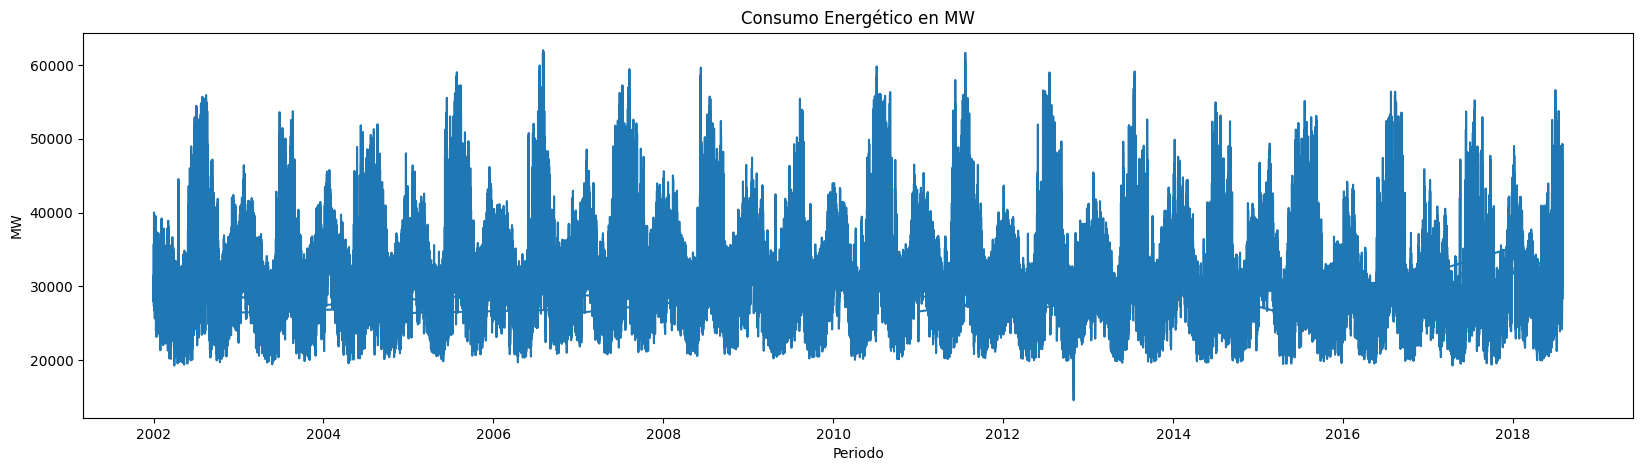

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 5))
plt.plot(df['Datetime'], df['PJME_MW'])
plt.xlabel('Periodo')
plt.ylabel('MW')
plt.title('Consumo Energético en MW')
plt.show()

## 4.2. Normalización, Scaling y División Entrenamiento-Validacion

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.5 pts.]:</strong> Normaliza el conjunto de datos, crea secuencias en ventanas y divide en conjuntos de entrenamiento y prueba.</p>
</div>




In [27]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Normalización por Maximo/Minimo
min_max_scaler = MinMaxScaler()
df['MW_scaled'] = min_max_scaler.fit_transform(df['PJME_MW'].values.reshape(-1, 1))
df.head()

,Datetime,PJME_MW,MW_scaled
0,2002-12-31 01:00:00,26498.0,0.251849
1,2002-12-31 02:00:00,25147.0,0.223386
2,2002-12-31 03:00:00,24574.0,0.211314
3,2002-12-31 04:00:00,24393.0,0.207500
4,2002-12-31 05:00:00,24860.0,0.217339


In [28]:
# Función para partir los datos en entrenamiento y prueba
def create_inpunt_sequences(data_scaled: pd.Series, window_size=1):
    # Lista para guardar las particiones
    X_list = []
    y_list = []
    for i in range(len(data_scaled) - window_size):
        X_list.append(data_scaled[i: i + window_size])
        y_list.append(data_scaled[i + 1: i + window_size+1])

    # Entradas con forma (samples, time_steps)
    X_array = np.array(X_list)
    y_array = np.array(y_list)

    # Keras requiere que la entrada sea (samples, time_steps, features)
    X_tensors = X_array[..., np.newaxis]
    y_tensors = y_array[..., np.newaxis]

    return X_tensors, y_tensors

In [29]:
# Conjunto de entrnamiento y test para una RNN
lookback = 24
X_data, y_data = create_inpunt_sequences(data_scaled=df['MW_scaled'], window_size=lookback)
print("X shape: ", X_data.shape)
print("y shape: ", y_data.shape)

from sklearn.model_selection import train_test_split

# Creamos conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.02, shuffle=False) # Shuffle=False para mantener la secuencia de los datos

print("X Training shape: ", X_train.shape)
print("X Testing shape: ", X_test.shape)
print("y Training shape: ", y_train.shape)
print("y Testing shape: ", y_test.shape)

X shape:  (145342, 24, 1)
y shape:  (145342, 24, 1)
X Training shape:  (142435, 24, 1)
X Testing shape:  (2907, 24, 1)
y Training shape:  (142435, 24, 1)
y Testing shape:  (2907, 24, 1)


## 4.3. Creación del Modelo (RNN, GRU, LSTM)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [1 pts.]:</strong> Crea tres modelos separados usando RNN Simple, GRU y LSTM. Los modelos tienen que tener 50 unidades de neuronas en la capa recurrente. Compila el modelo utilizando la función de pérdida `MSE` y el optimizador `adam`</p>
</div>




In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Dense

 # A 3D tensor, with shape [batch, timesteps, feature]

# RNN model
model_simple_rnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None, 1)),
    tf.keras.layers.SimpleRNN(50, return_sequences=True),
    tf.keras.layers.Dense(1)
])

# GRU model
model_gru_rnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None, 1)),
    tf.keras.layers.GRU(50, return_sequences=True),
    tf.keras.layers.Dense(1)
])

# LSTM model
model_lstm_rnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None, 1)),
    tf.keras.layers.LSTM(50, return_sequences=True),
    tf.keras.layers.Dense(1)
])

# Compilar los modelos
for model in [model_simple_rnn, model_gru_rnn, model_lstm_rnn]:
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [31]:
model_simple_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, None, 50)       │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 1)        │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model_gru_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, None, 50)       │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 1)        │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model_lstm_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, None, 50)       │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 1)        │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Some tutorials:
TensorFlow Tutorial 10 - Recurrent Neural Nets (RNN & LSTM & GRU)


## 4.4. Entrenar los Modelos y Graficar Curvas de Aprendizaje

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.5 pts.]:</strong> Entrena cada modelo y visualiza su rendimiento durante el entrenamiento.</p>
</div>




In [34]:
import os
import time
from tensorflow.keras.models import load_model

# Establecemos el directorio principal donde guardaremos los modelos entrenados comos sus resultados
save_model_output_path = "/content/drive/MyDrive/Colab Notebooks/DEEP_LEARNING_0/PEC02_RNN"
os.path.isdir(save_model_output_path)
#os.getcwd()

True

- Simple RNN

In [35]:
# Definir callbacks: EarlyStopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # monitorea la pérdida en validación
    patience=10, # esperar hasta 10 épocas sin mejora
    restore_best_weights=True # restaura los mejores pesos
    )

# Tiempo de entrenamiento
#simple_rnn_start_time = time.time()

# Entrenamos rnn simple
#simple_rnn_history = model_simple_rnn.fit(X_train, y_train, epochs=70, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

#simple_rnn_end_time = time.time()
#simple_rnn_total_time =  simple_rnn_end_time - simple_rnn_start_time
#print(f"Tiempo de entrenamiento: {simple_rnn_total_time:.2f} segundos")

In [36]:
# Guardar tiempo de entrenamiento - GPU
simple_rnn_model_training_time_secs = 666.46
print(f"Tiempo de entrenamiento: {simple_rnn_model_training_time_secs} segundos")

Tiempo de entrenamiento: 666.46 segundos


In [37]:
# Guardar el modelo entrenado en directorio
path_save_simple_rnn_model = os.path.join(save_model_output_path, "m01_simple_rnn_trained_model.keras")
#model_simple_rnn.save(path_save_simple_rnn_model)

# Guardamos el historial de los resultados del entrenamiento
path_save_simple_rnn_history = os.path.join(save_model_output_path, 'm01_simple_rnn_training_history.csv')
#simple_rnn_history_df = pd.DataFrame(simple_rnn_history.history)
#simple_rnn_history_df.to_csv(path_save_simple_rnn_history)

In [38]:
# Cargar el modelo guardado
from tensorflow.keras.models import load_model
loaded_simple_rnn_model = load_model(path_save_simple_rnn_model)
loaded_simple_rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, None, 50)       │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 1)        │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,955 (31.08 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,304 (20.72 KB)

In [39]:
# Cargamos el historial de resultados
rnn_history_df1 = pd.read_csv(path_save_simple_rnn_history)
rnn_history_df1.head(5)

,Unnamed: 0,loss,mae,val_loss,val_mae
0,0,0.000847,0.019681,0.000566,0.016130
1,1,0.000602,0.016957,0.000556,0.015786
2,2,0.000550,0.016100,0.000510,0.014856
3,3,0.000503,0.015239,0.000491,0.014861
4,4,0.000457,0.014269,0.000465,0.013922


- GRU

In [40]:
# Definir callbacks: EarlyStopping
early_stopping_gru = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # monitorea la pérdida en validación
    patience=10, # esperar hasta 10 épocas sin mejora
    restore_best_weights=True # restaura los mejores pesos
    )

# Tiempo de entrenamiento
#gru_rnn_start_time = time.time()

# Entrenamos rnn con GRU
#gru_rnn_history = model_gru_rnn.fit(X_train, y_train, epochs=70, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping_gru])

#gru_rnn_end_time = time.time()

# Mostramos tiempo de entrenamiento requerido
#gru_rnn_total_time =  gru_rnn_end_time - gru_rnn_start_time
#print(f"Tiempo de entrenamiento: {gru_rnn_total_time:.2f} segundos")

In [41]:
# Guardar tiempo de entrenamiento - CPU
gru_rnn_model_training_time_secs = 5109.44
print(f"Tiempo de entrenamiento: {gru_rnn_model_training_time_secs} segundos")

Tiempo de entrenamiento: 5109.44 segundos


In [42]:
# Guardar el modelo entrenado en directorio
from tensorflow.keras.models import load_model
path_save_gru_rnn_model = os.path.join(save_model_output_path, "m01_gru_rnn_trained_model.keras")
#model_gru_rnn.save(path_save_gru_rnn_model)

# Guardar el historial de los resultados del entrenamiento
path_save_gru_rnn_history = os.path.join(save_model_output_path, 'm01_gru_rnn_training_history.csv')
#gru_rnn_history_df = pd.DataFrame(gru_rnn_history.history)
#gru_rnn_history_df.to_csv(path_save_gru_rnn_history)

In [43]:
# Cargar el modelo guardado
loaded_gru_rnn_model = load_model(path_save_gru_rnn_model)
loaded_gru_rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, None, 50)       │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 1)        │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,005 (93.77 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,004 (62.52 KB)

In [44]:
# Cargar el historial de resultados
gru_rnn_history_df1 = pd.read_csv(path_save_gru_rnn_history)
gru_rnn_history_df1.head(5)

,Unnamed: 0,loss,mae,val_loss,val_mae
0,0,0.001742,0.024647,0.000528,0.015294
1,1,0.000513,0.015179,0.000514,0.014405
2,2,0.000499,0.014854,0.000493,0.014038
3,3,0.000481,0.014507,0.000486,0.013783
4,4,0.000438,0.013636,0.000430,0.012771


- LSTM

In [45]:
# Definir callbacks: EarlyStopping
early_stopping_lstm = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # monitorea la pérdida en validación
    patience=10, # esperar hasta 10 épocas sin mejora
    restore_best_weights=True # restaura los mejores pesos
    )

# Tiempo de entrenamiento
#lstm_rnn_start_time = time.time()

# Entrenamos rnn con LSTM
#lstm_rnn_history = model_lstm_rnn.fit( X_train, y_train, epochs=70, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping_lstm])

#lstm_rnn_end_time = time.time()

# Mostramos tiempo de entrenamiento requerido
#lstm_rnn_total_time =  lstm_rnn_end_time - lstm_rnn_start_time
#print(f"Tiempo de entrenamiento: {lstm_rnn_total_time:.2f} segundos")

In [46]:
# Guardar tiempo de entrenamiento - CPU
lstm_rnn_model_training_time_secs = 3223.01
print(f"Tiempo de entrenamiento: {lstm_rnn_model_training_time_secs} segundos")

Tiempo de entrenamiento: 3223.01 segundos


In [47]:
# Guardar el modelo entrenado en directorio
from tensorflow.keras.models import load_model
path_save_lstm_rnn_model = os.path.join(save_model_output_path, "m01_lstm_rnn_trained_model.keras")
#model_lstm_rnn.save(path_save_lstm_rnn_model)

# Guardar el historial de los resultados del entrenamiento
path_save_lstm_rnn_history = os.path.join(save_model_output_path, 'm01_lstm_rnn_training_history.csv')
#lstm_rnn_history_df = pd.DataFrame(lstm_rnn_history.history)
#lstm_rnn_history_df.to_csv(path_save_lstm_rnn_history)

In [48]:
# Cargar el modelo guardado
loaded_lstm_rnn_model = load_model(path_save_lstm_rnn_model)
loaded_lstm_rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, None, 50)       │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 1)        │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

In [49]:
# Cargar el historial de resultados
lstm_rnn_history_df1 = pd.read_csv(path_save_lstm_rnn_history)
lstm_rnn_history_df1.head(5)

,Unnamed: 0,loss,mae,val_loss,val_mae
0,0,0.002780,0.029698,0.000545,0.015202
1,1,0.000514,0.015182,0.000494,0.014210
2,2,0.000466,0.014305,0.000465,0.013552
3,3,0.000426,0.013461,0.000434,0.013050
4,4,0.000396,0.012744,0.000415,0.012457


- Comparativa curvas de aprendizaje

In [50]:
import matplotlib.pyplot as plt
# Función auxiliar para graficar MAE y loss
def plot_mae_loss_throught_epoch(df_history:pd.DataFrame):
    """Plots training & validation MAE and loss over epochs."""
    mae = df_history['mae']
    val_mae = df_history['val_mae']
    loss = df_history['loss']
    val_loss = df_history['val_loss']

    epochs_range = range(len(mae))

    plt.figure(figsize=(16, 8))

    # Plot MAE
    plt.subplot(2, 1, 1)
    plt.plot(epochs_range, mae, label='Training', marker='.', markersize=7)
    plt.plot(epochs_range, val_mae, label='Validation', marker='.', markersize=7)
    plt.ylabel('MAE')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.title('MAE: Training vs. Validation')

    # Plot Loss
    plt.subplot(2, 1, 2)
    plt.plot(epochs_range, loss, label='Training',  marker='.', markersize=7)
    plt.plot(epochs_range, val_loss, label='Validation',  marker='.', markersize=7)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.title('Loss: Training vs. Validation')
    plt.tight_layout()

    plt.show()

#### Simple RNN

La curva de errores cometidos es decreciente y suave conforme avanzamos en el tiempo. Hay overfitting, los errores en el conjunto de validadicón son superiores al conjunto de prueba.

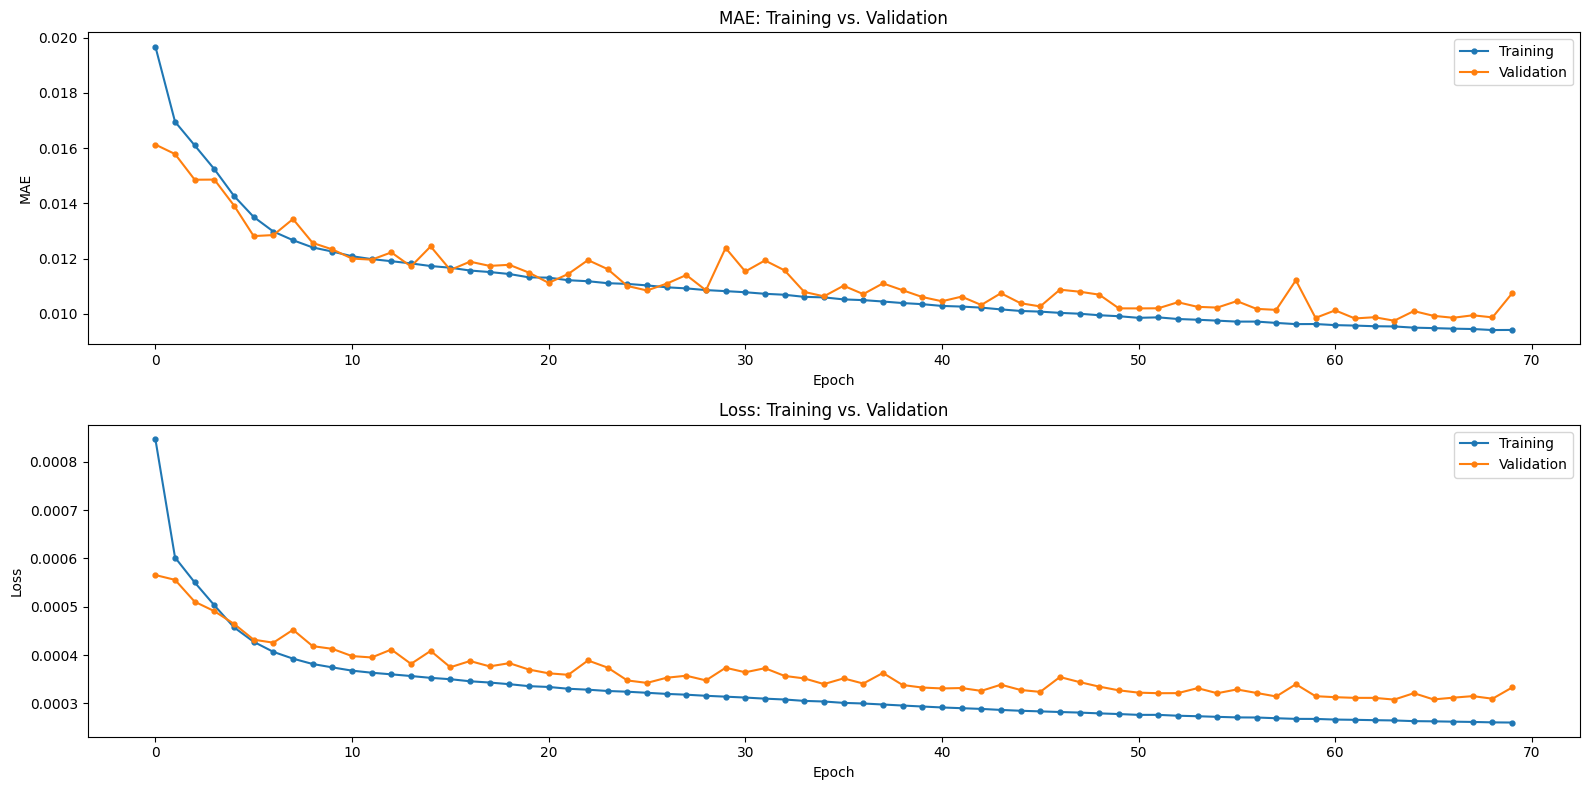

In [51]:
# Resultados
plot_mae_loss_throught_epoch(rnn_history_df1)

#### GRU

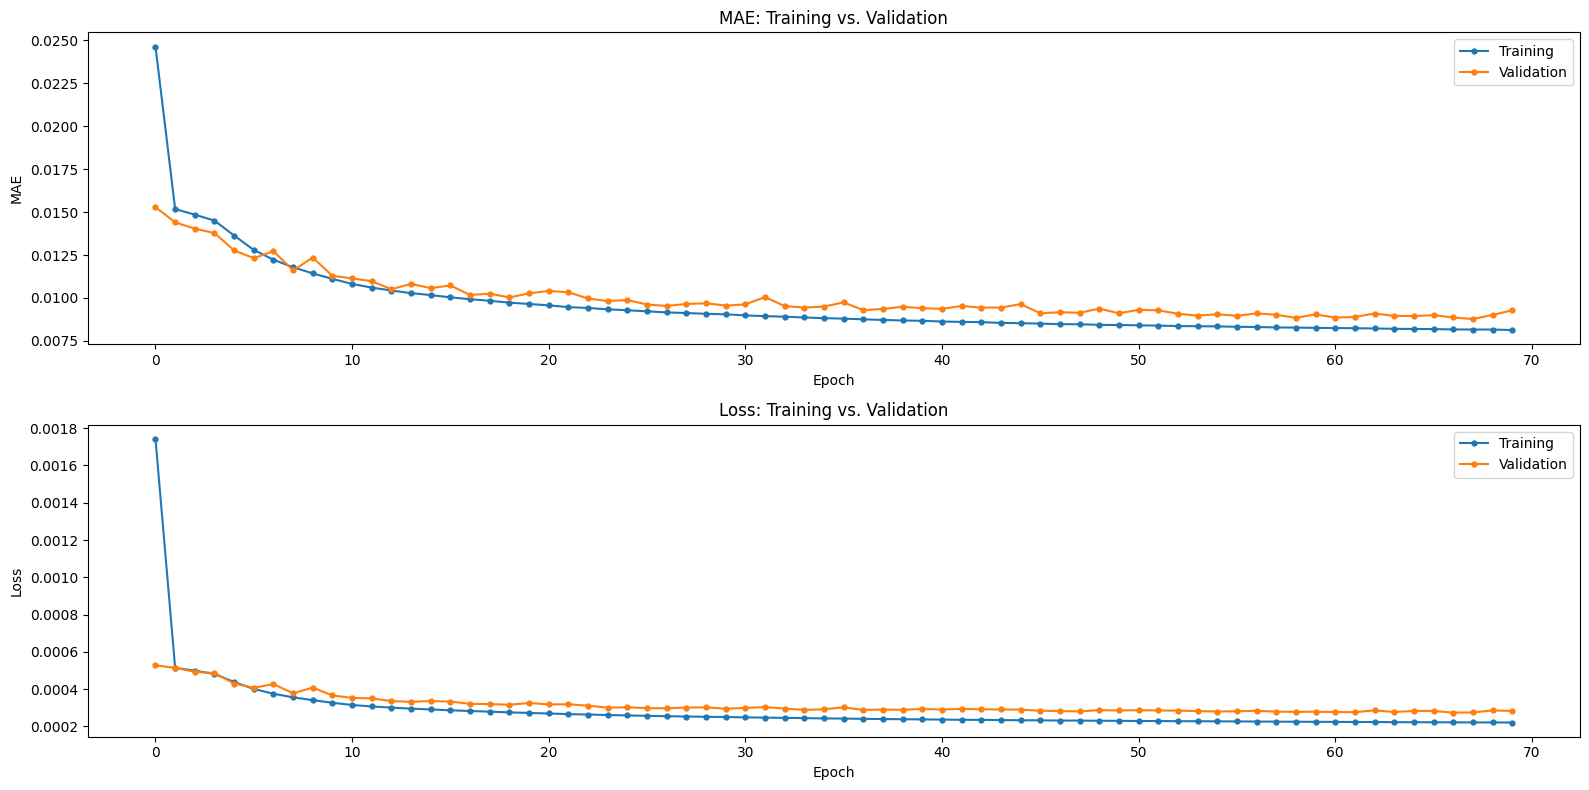

In [52]:
# Resultados
plot_mae_loss_throught_epoch(gru_rnn_history_df1)

#### LSTM

El conjunto de validación y entrenamiento evolucionan de forma casi equivalent.

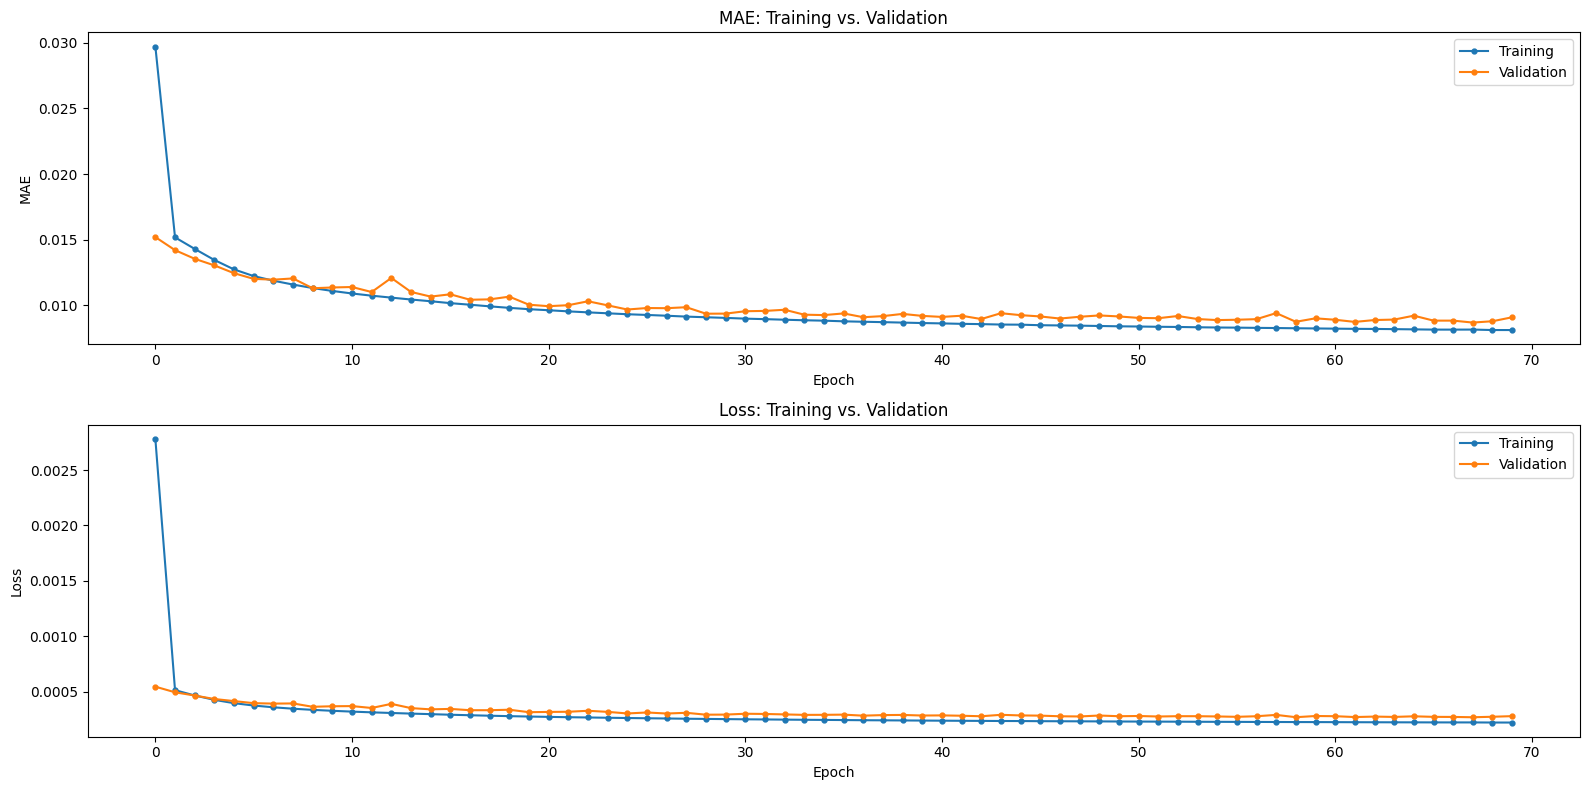

In [53]:
# Resultados
plot_mae_loss_throught_epoch(lstm_rnn_history_df1)

## 4.5. Hacer Predicciones Futuras y Comparar Rendimiento

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.5 pts.]:</strong> Predice valores futuros usando el conjunto de prueba y compara el rendimiento.</p>
</div>




91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


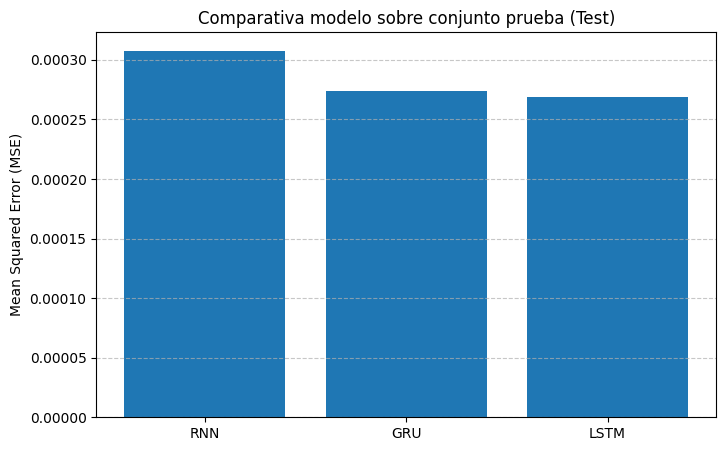

In [54]:
from sklearn.metrics import mean_squared_error

# Usamos el modelo entrenado con el conjunto de prueba
y_pred_rnn_simple = loaded_simple_rnn_model.predict(X_test)
y_pred_gru = loaded_gru_rnn_model.predict(X_test)
y_pred_lstm = loaded_lstm_rnn_model.predict(X_test)

y_simple_mse = mean_squared_error(y_test.flatten(), y_pred_rnn_simple.flatten())
y_gru_mse = mean_squared_error(y_test.flatten(), y_pred_gru.flatten())
y_lstm_mse = mean_squared_error(y_test.flatten(), y_pred_lstm.flatten())

# Leyendas
model_names = ['RNN', 'GRU', 'LSTM']
models_mse = [y_simple_mse, y_gru_mse, y_lstm_mse]

# Grafico de barras
plt.figure(figsize=(8, 5))
plt.bar(model_names, models_mse)
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Comparativa modelo sobre conjunto prueba (Test)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Tanto GRU como LSTM son casi equivalentes. Siendo GRU más rapido en el entrenamiento.

## 4.6. Experimentar con el Tamaño de Ventana

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.5 pts.]:</strong> Cambia el window_size para explorar cómo depende la predicción del intervalo de tiempo. Prueba por ejemplo con un tamaño de ventana de 48 horas.</p>
</div>




X shape:  (145318, 48, 1)
y shape:  (145318, 48, 1)
X Training shape:  (142411, 48, 1)
X Testing shape:  (2907, 48, 1)
y Training shape:  (142411, 48, 1)
y Testing shape:  (2907, 48, 1) 

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


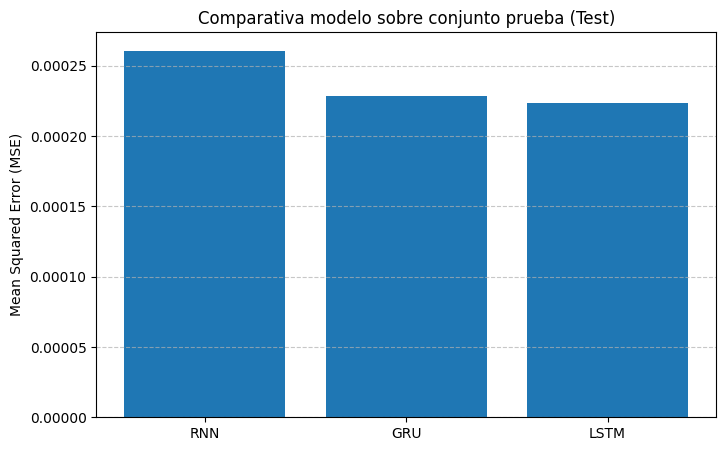

In [55]:
# Conjunto de entrnamiento y test para una RNN
lookback = 48
X_data_48, y_data_48 = create_inpunt_sequences(data_scaled=df['MW_scaled'], window_size=lookback)
print("X shape: ", X_data_48.shape)
print("y shape: ", y_data_48.shape)

from sklearn.model_selection import train_test_split

# Creamos conjunto de entrenamiento y prueba
X_trai_48, X_test_48, y_train_48, y_test_48 = train_test_split(X_data_48, y_data_48, test_size=0.02, shuffle=False) # Shuffle=False para mantener la secuencia de los datos

print("X Training shape: ", X_trai_48.shape)
print("X Testing shape: ", X_test_48.shape)
print("y Training shape: ", y_train_48.shape)
print("y Testing shape: ", y_test_48.shape, '\n')


# Usamos el modelo entrenado con el conjunto de prueba
y_pred_simple_48 = loaded_simple_rnn_model.predict(X_test_48)
y_pred_gru_48 = loaded_gru_rnn_model.predict(X_test_48)
y_pred_lstm_48 = loaded_lstm_rnn_model.predict(X_test_48)

y_simple_mse_48 = mean_squared_error(y_test_48.flatten(), y_pred_simple_48.flatten())
y_gru_mse_48 = mean_squared_error(y_test_48.flatten(), y_pred_gru_48.flatten())
y_lstm_mse_48 = mean_squared_error(y_test_48.flatten(), y_pred_lstm_48.flatten())

# Leyendas
model_names = ['RNN', 'GRU', 'LSTM']
models_mse_results_48 = [y_simple_mse_48, y_gru_mse_48, y_lstm_mse_48]

# Grafico de barras
plt.figure(figsize=(8, 5))
plt.bar(model_names, models_mse_results_48)
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Comparativa modelo sobre conjunto prueba (Test)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Los modelos están entrenados con datos con ventana 24. Sorprende que con una ventana de 48 los errores cometidos sean más bajos.

## 4.7. Modelo LSTM Profundo con Optimización de Hiperparámetros usando Optuna

Construir un modelo LSTM más profundo (con más capas) y utilizar Optuna para optimizar hiperparámetros clave. Luego comparar su rendimiento con los modelos anteriores (RNN, GRU y LSTM básico)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [1.75 pts.]:</strong> Definición del Modelo LSTM Profundo. Vamos a crear un modelo con:

<ul>
 <li>2 capas LSTM (con return_sequences=True en la primera para apilarlas).</li>
 <li>Capa Densa final.</li>
 <li>Dropout para regularización (evitar overfitting).</li>
 </ul>

Después toca definir hiperparámetros a Optimizar con Optuna.Optuna buscará la mejor combinación de:

 <ul>
  <li>Número de neuronas en cada capa LSTM: Entre 32 y 128.</li>
  <li>Tasa de Dropout: Entre 0.1 y 0.5.</li>
  <li>Tasa de aprendizaje (learning rate): Entre 1e-4 y 1e-2 (log scale).</li>
  <li>Batch size: 32, 64 o 128.</li>
 </ul>


 Por último, evalúa y compara con los modelos anteriores. Para ello te proporcionamos el código para mejor legibilidad.

 </p>

</div>





In [56]:
!pip install optuna # Recuerda instalar en caso de no tenerlo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 13.4 MB/s eta 0:00:00


In [57]:
def build_model(lstm_units=64, dropout_rate=0.3, learning_rate=1e-3):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(24, 1)),
        tf.keras.layers.LSTM(lstm_units, return_sequences=True),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.LSTM(lstm_units),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse',
                  metrics=['mae'])
    return model

In [58]:
import optuna
def objective(trial):
    # Suggest hyperparameters
    lstm_units = trial.suggest_categorical('lstm_units', [32, 64, 128])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    model = build_model(lstm_units, dropout_rate, learning_rate)

    # Train model with validation split
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=batch_size,
        verbose=0
    )

    # Evaluate on validation data
    val_loss = min(history.history['val_loss'])
    return val_loss

In [59]:
# Completa el ejercicio
window_size = 24  # Usando las últimas 24 horas para predecir la siguiente hora
X, y = [], []

data_scaled = df['MW_scaled']
for i in range(len(data_scaled) - window_size):
    X.append(data_scaled[i:i + window_size])
    y.append(data_scaled[i + window_size])

X, y = np.array(X), np.array(y)

split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

X_train_tensor = X_train[..., np.newaxis]
X_test_tensor = X_test[..., np.newaxis]
y_train_tensor = y_train[..., np.newaxis]
y_test_tensor = y_test[..., np.newaxis]

print(X_train_tensor.shape)

(116273, 24)
(29069, 24)
(116273,)
(29069,)
(116273, 24, 1)


In [60]:
#study = optuna.create_study(direction='minimize')
#study.optimize(objective, n_trials=3)

In [61]:
#print("Best trial:")
#trial = study.best_trial
#print(f"LSTM units: {trial.params['lstm_units']}")
#print(f"Dropout rate: {trial.params['dropout_rate']}")
#print(f"Learning rate: {trial.params['learning_rate']}")
#print(f"Batch size: {trial.params['batch_size']}")



```
# This is formatted as code
[I 2025-04-16 15:03:41,856] A new study created in memory with name: no-name-93e1fc24-7703-4eb1-a92d-6e47fb669197
[I 2025-04-16 15:23:46,605] Trial 0 finished with value: 0.0002516412059776485 and parameters: {'lstm_units': 32, 'dropout_rate': 0.10626595220607636, 'learning_rate': 0.0005282791678279837, 'batch_size': 128}. Best is trial 0 with value: 0.0002516412059776485.
[I 2025-04-16 16:26:43,522] Trial 1 finished with value: 0.0002467244921717793 and parameters: {'lstm_units': 64, 'dropout_rate': 0.13503061988264872, 'learning_rate': 0.00013305729315562004, 'batch_size': 32}. Best is trial 1 with value: 0.0002467244921717793.
[I 2025-04-16 17:31:20,010] Trial 2 finished with value: 0.00015487689233850688 and parameters: {'lstm_units': 64, 'dropout_rate': 0.2441752005869644, 'learning_rate': 0.0012177412844357187, 'batch_size': 32}. Best is trial 2 with value: 0.00015487689233850688.
```



Pausamos modelo entrenado

In [62]:
# Guardamos los mejores parametros
# deep_lstm_best_params = trial.params # diccionario

# Actualizamos el modelo con estos mejores valores

model_deep_lstm = build_model(
    lstm_units= 64, # deep_lstm_best_params['lstm_units'],
    dropout_rate= 0.2441752005869644, # deep_lstm_best_params['dropout_rate'],
    learning_rate= 0.0012177412844357187, # deep_lstm_best_params['learning_rate']
    )

# Entrenamos el modelo con estos parámetros
# model_deep_lstm.fit(X_train_tensor, y_train_tensor, epochs=50, batch_size=32, validation_data=(X_test_tensor, y_test_tensor))

In [63]:
# Guardar el modelo entrenado en directorio
from tensorflow.keras.models import load_model
path_save_deep_lstm_rnn_model = os.path.join(save_model_output_path, "m01_deep_lstm_rnn_trained_model.keras")
#model_lstm_rnn.save(path_save_deep_lstm_rnn_model)

# Cargar el modelo guardado
loaded_deep_lstm_rnn_model = load_model(path_save_deep_lstm_rnn_model)
loaded_deep_lstm_rnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, None, 50)       │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 1)        │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

In [64]:
# Cargar el historial de resultados
#deep_lstm_rnn_history_df1 = pd.read_csv(path_save_lstm_rnn_history)
#deep_lstm_rnn_history_df1.head(5)

In [65]:
# Evaluar el modelo profundo
y_pred_deep_lstm = loaded_deep_lstm_rnn_model.predict(X_test_tensor)
deep_lstm_mse = mean_squared_error(X_test_tensor.flatten(), y_pred_deep_lstm.flatten())

print(f"MSE (Deep LSTM + Optuna): {deep_lstm_mse:.6f}")

# Comparar con modelos anteriores (ejercicio 5)
print("Comparación de MSE:")
print(f"- RNN: {y_simple_mse:.6f}")
print(f"- GRU: {y_gru_mse:.6f}")
print(f"- LSTM básico: {y_lstm_mse:.6f}")
print(f"- LSTM profundo + Optuna: {deep_lstm_mse:.6f}")

909/909 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step
MSE (Deep LSTM + Optuna): 0.196399
Comparación de MSE:
- RNN: 0.000308
- GRU: 0.000274
- LSTM básico: 0.000269
- LSTM profundo + Optuna: 0.196399


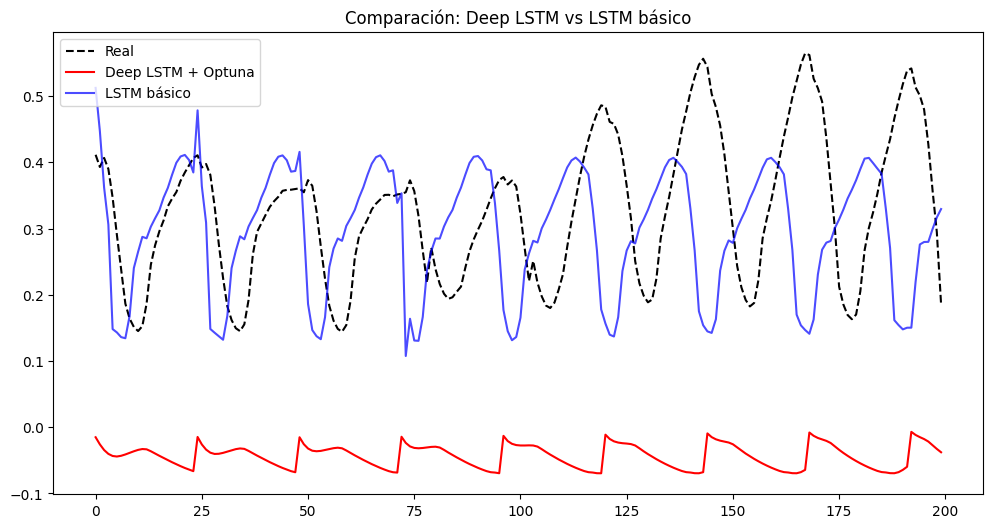

In [66]:
# Gráfico comparativo de predicciones (primeras 200 muestras)
plt.figure(figsize=(12, 6))
plt.plot(y_test.flatten()[:200], label='Real', color='black', linestyle='--')
plt.plot(y_pred_deep_lstm.flatten()[:200], label='Deep LSTM + Optuna', color='red')
plt.plot(y_pred_lstm.flatten()[:200], label='LSTM básico', color='blue', alpha=0.7)
plt.legend()
plt.title("Comparación: Deep LSTM vs LSTM básico")
plt.show()

El modelo optimizado tiene uan peor capacidad predictiva. Esto es porque la busqueda ha sido limitada a tres tipos de combinaciones dada la falta de recursos computacionales como comprensión del proceso.

# Referencias

[1] Kumaran Ponnambalam. Recurrent Neural Networks. (2024). [Linkedin Learning]. Localización: https://www.linkedin.com/learning/recurrent-neural-networks/getting-started-with-rnns (Consultado en: 11 Abril 2025)

[2] Mehreen Saeed. Understanding Simple Recurrent Neural Networks in Keras.(2023). [machinelearningmastery]. Localización: https://machinelearningmastery.com/understanding-simple-recurrent-neural-networks-in-keras/ (Consultado en: 12 Abril 2025)

[3] Anishnama. Understanding Gated Recurrent Unit (GRU) in Deep Learning. (2023). [Medium]. Localización: https://medium.com/@anishnama20/understanding-gated-recurrent-unit-gru-in-deep-learning-2e54923f3e2. (Consultado en: 13 Abril 2025)

[4] Dataquest. RNN From Scratch In Python. (2023). [YouTube]. Localización: https://www.youtube.com/watch?v=4wuIOcD1LLI&t=2097s (Consultado en: 13 Abril 2025)

[5] Tensorflow. Time series forecasting. Localización: https://www.tensorflow.org/tutorials/structured_data/time_series (Consultado en: 13 Abril 2025)

[6] Tensorflow. [tf.keras.layers.GRU]. Localización: https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU (Consultado en: 13 Abril 2025)

[7] Anishnama. Understanding LSTM: Architecture, Pros and Cons, and Implementation. (2023). [Medium]. Localización: https://medium.com/@anishnama20/understanding-lstm-architecture-pros-and-cons-and-implementation-3e0cca194094 (Consultado en: 14 Abril 2025)

[8] Tensorflow. [tf.keras.layers.LSTM]. Localización: https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM (Consultado en: 14 Abril 2025)

[9] Ferneutron. Optimización de Hyperparametros con Optuna | Python | Scikit-Learn. [YouTube]. Localización: https://www.youtube.com/watch?v=87L5NzwQXLI (Consultado en: 15 Abril 2025)

[10] Geir Drange. Keras model tuning with Optuna. [Kaggle]. Localización: https://www.kaggle.com/code/mistag/keras-model-tuning-with-optuna(Consultado 16 Abril 2025)

In [68]:
#!pip install nbconvert
from google.colab import files

!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/DEEP_LEARNING_0/PEC02_RNN/vguiaan_PEC02.ipynb" --to html
files.download("/content/drive/MyDrive/Colab Notebooks/DEEP_LEARNING_0/PEC02_RNN/vguiaan_PEC02.html")

#!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/DEEP_LEARNING_0/PEC02_RNN/vguiaan_PEC2.ipynb"
#files.download("/content/drive/MyDrive/Colab Notebooks/DEEP_LEARNING_0/PEC02_RNN/vguiaan_PEC2.html")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/DEEP_LEARNING_0/PEC02_RNN/vguiaan_PEC02.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 1283820 bytes to /content/drive/MyDrive/Colab Notebooks/DEEP_LEARNING_0/PEC02_RNN/vguiaan_PEC02.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>